# Pipeline — Génération des variantes (data_final_pipeline.csv)

    - Excution du pipeline.py
    - Exploration de sortie des LLms, 
    - retraitement des ids echouees
    - Manipulation/testes sur le dataset de sortie. 

In [2]:
# gestiion des bibliotheques et des imports
import os
import json
import time
import csv
import ast
import asyncio
import pandas as pd
import numpy as np
from openai import AsyncOpenAI
from dotenv import load_dotenv
from datetime import datetime
from IPython.display import display
import nest_asyncio
nest_asyncio.apply()
from importlib import reload
from datetime import datetime
import pipelie_recette
reload(pipelie_recette)
from pipelie_recette import run_from_notebook
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ast
load_dotenv()

True

## Verification finale du dataset avant de l'envoyer dans le pipeline

In [ ]:
input_path = "data_final_pipeline.csv"
df_input = pd.read_csv(input_path)

# Remplir le 1 NaN dans ingredient
df_input["ingredient"] = df_input["ingredient"].fillna("")

df_input.head(10) 

,id,title,instruction,ingredient
0,000095fc1d,Yogurt Parfaits,Layer all ingredients in a serving dish.,"8 ounces, weight Light Fat Free Vanilla Yogurt..."
1,000320b7ce,Tropical Banana Muffins,Heat oven to 375F. Place paper baking cups int...,2 cups all-purpose flour 2 teaspoons baking po...
2,001078d812,Reuben in the Round,"In large bowl, stir together all ingredients e...",1 (16 ounce) container sour cream 12 cup thous...
3,0010cad8ab,Garlic and Dill Salmon,"In a food processor, process garlic to a rough...","2 (1.5 pound) salmon fillets 1 head garlic, pe..."
4,001404a16f,Bacon Avocado Deviled Eggs,Prepare eggs by placing in a single layer in a...,"12 whole Eggs 5 slices Bacon, Cooked And Crumb..."
5,00154ea0c2,Chestnut-Apple Soup With Calvados Cream,Place prunes in a small bowl and add boiling w...,"10 pitted prunes 1/4 cup Calvados or Cognac, m..."
6,001577ef97,How to Boil Water,Open your cupboard or wherever it is you store...,water salt (optional)
7,0018861236,Corn Salad,Cut corn off the cob into a bowl. Chop one tom...,leftover corn on the cob or canned corn ripe t...
8,0019ae8eca,Smoked Turkey Club Salad,"Arrange turkey, tomato and bacon over greens o...",1 pkg. (5.5 oz.) LOUIS RICH CARVING BOARD Smok...
9,001ab60ef2,Muffins Basic and Variations,Grease 12 2 1/2-inch muffin cups. Heat oven to...,2 cups unbleached all-purpose flour 1 tablespo...


In [5]:
df_input.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34591 entries, 0 to 34590
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           34591 non-null  object
 1   title        34591 non-null  object
 2   instruction  34591 non-null  object
 3   ingredient   34591 non-null  object
dtypes: object(4)
memory usage: 1.1+ MB


In [6]:
print(f"Nombre de recettes à traiter : {len(df_input):,}")
print(f"Colonnes : {list(df_input.columns)}")
print(f"IDs uniques : {df_input['id'].nunique():,}")
print(f"Valeurs manquantes :\n{df_input.isna().sum()}")

Nombre de recettes à traiter : 34,591
Colonnes : ['id', 'title', 'instruction', 'ingredient']
IDs uniques : 34,591
Valeurs manquantes :
id             0
title          0
instruction    0
ingredient     0
dtype: int64


## Gestion du pipeline - excution 

In [6]:
from importlib import reload
import pipelie_recette
reload(pipelie_recette)
from pipelie_recette import run_from_notebook

df_results, csv_path, json_path, checkpoint_path = run_from_notebook(
    df_input,
    checkpoint_path="data_checkpoint.jsonl",
    failed_path="data_echouee.jsonl",
    output_prefix="data_variantes",
    max_concurrent=10,   # analyse de 10 recette de facon parallele 
)

print(csv_path)
print(json_path)

PIPELINE VARIANTS - 34591 flags
Modeles: meta-llama/llama-3.3-70b-instruct, openai/gpt-4o-mini, mistralai/mistral-small-3.1-24b-instruct
Concurrence: 10 requetes simultanees

Reprise: 17813 deja traites


Recettes:  53%|█████▎    | 18442/34591 [06:15<2:37:18,  1.71it/s]

ID 8671fcc7ec invalid output [meta-llama/llama-3.3-70b-instruct] retry 1/3: Logical order error in variante_ingredients: 'serve' must be the final action


Recettes:  57%|█████▋    | 19692/34591 [15:40<2:00:40,  2.06it/s]

ID 91c7714329 invalid output [meta-llama/llama-3.3-70b-instruct] retry 1/3: Logical order error in variante_ingredients: 'serve' must be the final action


...

ID e7c622a4c1 invalid output [meta-llama/llama-3.3-70b-instruct] retry 1/3: Logical order error in variante_principale: 'enjoy' must be the final action


Recettes: 100%|█████████▉| 34456/34591 [2:10:57<01:03,  2.11it/s]

ID feda76dc0b invalid output [meta-llama/llama-3.3-70b-instruct] retry 1/3: Logical order error in variante_ingredients: 'serve' must be the final action


Recettes: 100%|██████████| 34591/34591 [2:11:56<00:00,  2.12it/s]


FAILED: 0
data_variantes_20260318_1758.csv
data_variantes_20260318_1758.json


- Note: comme mentionner lors de la presentation, le `FAILED`=0 est simplement du au faite que j'ai interrompu le pipeline a chaque fois que j'avais des erreurs sans me rendre compte que je n'avais de pas balise place afin de reprendre la ou j'interrompais le pipeline

## Vérification des échecs et des réussites

In [7]:
data_checkpoint  = "data_checkpoint.jsonl"
data_echouee     = "data_echouee.jsonl"

df_succes = pd.read_json(data_checkpoint, lines=True)
df_echec  = pd.read_json(data_echouee, lines=True)

In [8]:
print(f"Taille initiale du dataset : {len(df_input):,} recettes")
print(f"Recettes réussies          : {len(df_succes):,}")
print(f"Recettes échouées          : {len(df_echec):,}")

pct_succes = len(df_succes) / len(df_input) * 100
pct_echec  = len(df_echec)  / len(df_input) * 100
print(f"Taux de réussite           : {pct_succes:.2f}%")
print(f"Taux d'échec               : {pct_echec:.2f}%")

Taille initiale du dataset : 34,591 recettes
Recettes réussies          : 34,591
Recettes échouées          : 0
Taux de réussite           : 100.00%
Taux d'échec               : 0.00%


# Reprise des recettes échouées

In [ ]:
from importlib import reload
from datetime import datetime
import pipelie_recette
reload(pipelie_recette)
from pipelie_recette import run_from_notebook

checkpoint_path   = "data_checkpoint.jsonl"
failed_path       = "data_echouee.jsonl"
retry_failed_path = f"data_echouee_retry_{datetime.now():%Y%m%d_%H%M}.jsonl"

# 1) Charger les échecs et retirer les doublons
df_echec = pd.read_json(failed_path, lines=True).drop_duplicates("id")
df_echec["id"] = df_echec["id"].astype(str).str.strip()

# 2) Ne garder que les IDs qui ne sont pas déjà réussis
df_done  = pd.read_json(checkpoint_path, lines=True)
done_ids = set(df_done["id"].astype(str).str.strip())
df_a_relancer = df_echec[~df_echec["id"].isin(done_ids)][["id", "title", "instruction", "ingredient"]]

print(f"Échecs historiques   : {len(df_echec)}")
print(f"Déjà réussis         : {len(done_ids)}")
print(f"À relancer maintenant: {len(df_a_relancer)}")

# 3) Relancer le pipeline sur ce sous-ensemble
_ = run_from_notebook(
    df_a_relancer,
    checkpoint_path=checkpoint_path,
    failed_path=retry_failed_path,
    output_prefix="data_variantes_retry",
    save_outputs=False,
    log_every=20,
)

# 4) Vérification rapide après relance
df_succes_apres = pd.read_json(checkpoint_path, lines=True)
df_echec_retry  = pd.read_json(retry_failed_path, lines=True) if os.path.exists(retry_failed_path) else pd.DataFrame()

print(f"Succès totaux après relance     : {len(df_succes_apres)}")
print(f"Échecs restants (fichier retry) : {len(df_echec_retry)}")
print(f"Fichier d'échecs de relance     : {retry_failed_path}")

# Test de conformité structurelle - debut 

In [9]:
import ast
chemin_jsonl = "data_checkpoint.jsonl"
chemin_csv   = "data_variantes_flags.csv"

CHAMPS_ATTENDUS         = ["id", "variante_principale", "variante_ingredients", "variante_permutation"]
ENSEMBLE_CHAMPS_ATTENDUS = set(CHAMPS_ATTENDUS)
CHAMPS_LISTES            = ["variante_principale", "variante_ingredients", "variante_permutation"]


def est_chaine_non_vide(valeur):
    return isinstance(valeur, str) and valeur.strip() != ""


def verifier_jsonl(chemin):
    rapport = {k: 0 for k in ["lignes_totales", "json_malforme", "cles_invalides",
                                "id_invalide", "type_liste_invalide", "liste_vide", "element_liste_non_chaine"]}
    exemples_erreurs = []
    with open(chemin, "r", encoding="utf-8") as f:
        for num, ligne in enumerate(f, 1):
            ligne = ligne.strip()
            if not ligne:
                continue
            rapport["lignes_totales"] += 1
            try:
                obj = json.loads(ligne)
            except Exception:
                rapport["json_malforme"] += 1
                continue
            if set(obj.keys()) != ENSEMBLE_CHAMPS_ATTENDUS:
                rapport["cles_invalides"] += 1
                exemples_erreurs.append(("cles_invalides", num, list(obj.keys())))
            if not est_chaine_non_vide(obj.get("id")):
                rapport["id_invalide"] += 1
            for champ in CHAMPS_LISTES:
                val = obj.get(champ)
                if not isinstance(val, list):
                    rapport["type_liste_invalide"] += 1
                elif len(val) == 0:
                    rapport["liste_vide"] += 1
                elif any(not isinstance(e, str) for e in val):
                    rapport["element_liste_non_chaine"] += 1
    return rapport, exemples_erreurs


def verifier_csv(chemin):
    rapport = {k: 0 for k in ["lignes_totales", "entete_invalide", "id_invalide",
                                "erreur_parse_liste", "liste_parsee_non_liste", "liste_vide", "element_liste_non_chaine"]}
    exemples_erreurs = []
    with open(chemin, "r", encoding="utf-8", newline="") as f:
        lecteur = csv.DictReader(f)
        if lecteur.fieldnames != CHAMPS_ATTENDUS:
            rapport["entete_invalide"] += 1
        for num, ligne in enumerate(lecteur, 2):
            rapport["lignes_totales"] += 1
            if not est_chaine_non_vide(ligne.get("id")):
                rapport["id_invalide"] += 1
            for champ in CHAMPS_LISTES:
                brut = ligne.get(champ, "")
                try:
                    val = ast.literal_eval(brut)
                except Exception:
                    rapport["erreur_parse_liste"] += 1
                    continue
                if not isinstance(val, list):
                    rapport["liste_parsee_non_liste"] += 1
                elif len(val) == 0:
                    rapport["liste_vide"] += 1
                elif any(not isinstance(e, str) for e in val):
                    rapport["element_liste_non_chaine"] += 1
    return rapport, exemples_erreurs


rapport_jsonl, erreurs_jsonl = verifier_jsonl(chemin_jsonl)
rapport_csv,   erreurs_csv   = verifier_csv(chemin_csv)

print("=== RAPPORT JSONL ===")
for k, v in rapport_jsonl.items():
    print(f"  {k}: {v}")

print("\n=== RAPPORT CSV ===")
for k, v in rapport_csv.items():
    print(f"  {k}: {v}")

print("\n=== EXEMPLES D'ERREURS (max 10) ===")
for e in (erreurs_jsonl + erreurs_csv)[:10]:
    print(e)

print("\nConformité structurelle vérifiée.")

=== RAPPORT JSONL ===
  lignes_totales: 34591
  json_malforme: 0
  cles_invalides: 0
  id_invalide: 0
  type_liste_invalide: 0
  liste_vide: 0
  element_liste_non_chaine: 0

=== RAPPORT CSV ===
  lignes_totales: 34591
  entete_invalide: 0
  id_invalide: 0
  erreur_parse_liste: 0
  liste_parsee_non_liste: 0
  liste_vide: 0
  element_liste_non_chaine: 0

=== EXEMPLES D'ERREURS (max 10) ===

Conformité structurelle vérifiée.


# Statistiques finales

STATISTIQUES SORTIE PIPELINE LLM
Total envoyé    : 34,591
Succès          : 34,591  (100.00%)
Échecs définitifs: 0  (0.00%)


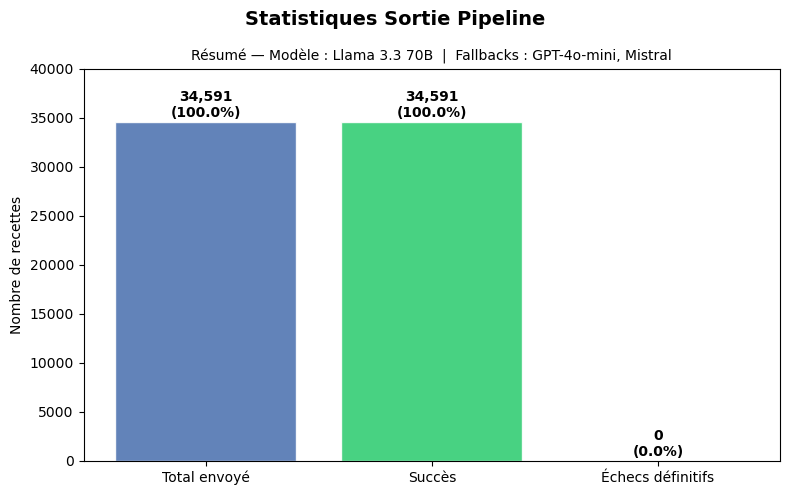

Graphique sauvegardé : img/data_stats_pipeline.png


In [10]:
import matplotlib.pyplot as plt
import ast
total     = len(df_input)
nb_succes = len(pd.read_csv(chemin_csv))
nb_echecs = len(df_echec_retry) if 'df_echec_retry' in dir() else len(pd.read_json("data_echouee.jsonl", lines=True))

print("=" * 60)
print("STATISTIQUES SORTIE PIPELINE LLM")
print("=" * 60)
print(f"Total envoyé    : {total:,}")
print(f"Succès          : {nb_succes:,}  ({nb_succes/total*100:.2f}%)")
print(f"Échecs définitifs: {nb_echecs}  ({nb_echecs/total*100:.2f}%)")

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Statistiques Sortie Pipeline", fontsize=14, fontweight="bold")

categories = ["Total envoyé", "Succès", "Échecs définitifs"]
valeurs    = [total, nb_succes, nb_echecs]
bar_colors = ["#4C72B0", "#2ecc71", "#e74c3c"]
bars = ax.bar(categories, valeurs, color=bar_colors, edgecolor="white", alpha=0.88)
ax.set_title("Résumé — Modèle : Llama 3.3 70B  |  Fallbacks : GPT-4o-mini, Mistral", fontsize=10)
ax.set_ylabel("Nombre de recettes")
ax.set_ylim(0, 40_000)
for bar, val in zip(bars, valeurs):
    pct = val / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{val:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("img/data_stats_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/data_stats_pipeline.png")

# Analyse des Séquences d'Actions

In [ ]:
import ast

# ── Charger le checkpoint
data_wide = pd.read_json("data_checkpoint.jsonl", lines=True)

# ── Parser les listes d'actions 
def parse_actions(val):
    if isinstance(val, list):
        return val
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(str(val))
    except Exception:
        return []

data_wide["actions_principale"]  = data_wide["variante_principale"].apply(parse_actions)
data_wide["actions_ingredients"] = data_wide["variante_ingredients"].apply(parse_actions)
data_wide["actions_permutation"] = data_wide["variante_permutation"].apply(parse_actions)
data_wide["nb_principale"]  = data_wide["actions_principale"].apply(len)
data_wide["nb_ingredients"] = data_wide["actions_ingredients"].apply(len)
data_wide["nb_permutation"] = data_wide["actions_permutation"].apply(len)

print(f"Recettes chargées : {len(data_wide):,}")
print(f"Colonnes          : {list(data_wide.columns)}")
print()
for variante in ["nb_principale", "nb_ingredients", "nb_permutation"]:
    s = data_wide[variante]
    print(f"[{variante}]  moy={s.mean():.2f}  méd={s.median():.1f}  min={s.min()}  max={s.max()}")

Recettes chargées : 34,591
Colonnes          : ['id', 'variante_principale', 'variante_ingredients', 'variante_permutation', 'actions_principale', 'actions_ingredients', 'actions_permutation', 'nb_principale', 'nb_ingredients', 'nb_permutation']

[nb_principale]  moy=5.89  méd=6.0  min=3  max=25
[nb_ingredients]  moy=8.75  méd=8.0  min=4  max=27
[nb_permutation]  moy=5.89  méd=6.0  min=3  max=25


## Classification Catégorie Cuisine

In [ ]:
# mots cles presents par categorie pour la classification des recettes 
BAKERY_KW    = ['bread','cake','cookie','muffin','pastry','pie','biscuit','scone',
                'croissant','brownie','tart','quiche','waffle','pancake','crepe',
                'roll','loaf','bun','donut']
STEW_KW      = ['stew','soup','broth','casserole','ragout','chili','chowder','gumbo',
                'bisque','bouillabaisse','curry','tagine','pot']
QUICK_KW     = ['salad','dip','dressing','snack','sandwich','wrap','sushi','smoothie',
                'juice','cocktail','parfait','bruschetta','ceviche','guacamole']

def classify_category(title):
    if pd.isna(title):
        return 'other'
    t = title.lower()
    if any(k in t for k in BAKERY_KW):   return 'bakery'
    if any(k in t for k in STEW_KW):     return 'stew'
    if any(k in t for k in QUICK_KW):    return 'quick_prep'
    return 'other'

# ── Merger avec les titres depuis df_input
data_wide = data_wide.merge(df_input[["id", "title"]], on="id", how="left")
data_wide["category"] = data_wide["title"].apply(classify_category)

print("Distribution des catégories :")
for cat, count in data_wide["category"].value_counts().items():
    pct = count / len(data_wide) * 100
    print(f"  {cat:<12} {count:>7,}  ({pct:.1f}%)")

Distribution des catégories :
  other         17,369  (50.2%)
  quick_prep     6,879  (19.9%)
  bakery         6,027  (17.4%)
  stew           4,316  (12.5%)


## Classification Complexité

In [ ]:
# ── Charger les métadonnées (nb steps réels) 
df_recipes = pd.read_csv("recipes.csv")[["id", "number_of_steps", "number_of_ingredients"]]

# ── Classifier la complexité 
def classify_complexity(nb_steps):
    if pd.isna(nb_steps): return 'simple'
    if nb_steps <= 10:    return 'simple'
    elif nb_steps <= 20:  return 'moyenne'
    else:                 return 'elevee'

df_recipes["complexity"] = df_recipes["number_of_steps"].apply(classify_complexity)

# ── Merger dans df_wide 
data_wide = data_wide.merge(df_recipes, on="id", how="left")

print("Distribution de la complexité :")
for cplx, count in data_wide["complexity"].value_counts().items():
    pct = count / len(data_wide) * 100
    print(f"  {cplx:<10} {count:>7,}  ({pct:.1f}%)")

print()
print("Nb actions par complexité (variante_principale) :")
for cplx in ["simple", "moyenne", "elevee"]:
    sub = data_wide[data_wide["complexity"] == cplx]["nb_principale"]
    if len(sub) > 0:
        print(f"  [{cplx}]  n={len(sub):,}  moy={sub.mean():.2f}  méd={sub.median():.1f}  min={sub.min()}  max={sub.max()}")

print()
print("Nb actions par catégorie (variante_principale) :")
for cat in ["bakery", "stew", "quick_prep", "other"]:
    sub = data_wide[data_wide["category"] == cat]["nb_principale"]
    if len(sub) > 0:
        print(f"  [{cat}]  n={len(sub):,}  moy={sub.mean():.2f}  méd={sub.median():.1f}  min={sub.min()}  max={sub.max()}")

Distribution de la complexité :
  simple      20,062  (58.0%)
  moyenne     10,213  (29.5%)
  elevee       4,316  (12.5%)

Nb actions par complexité (variante_principale) :
  [simple]  n=20,062  moy=5.11  méd=5.0  min=3  max=19
  [moyenne]  n=10,213  moy=6.80  méd=6.0  min=3  max=25
  [elevee]  n=4,316  moy=7.32  méd=7.0  min=3  max=21

Nb actions par catégorie (variante_principale) :
  [bakery]  n=6,027  moy=6.63  méd=6.0  min=3  max=19
  [stew]  n=4,316  moy=6.15  méd=6.0  min=3  max=17
  [quick_prep]  n=6,879  moy=5.03  méd=5.0  min=3  max=17
  [other]  n=17,369  moy=5.90  méd=6.0  min=3  max=25


### Graphiques — Catégorie

/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_96550/2331156485.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_cat, labels=cat_order, patch_artist=True,


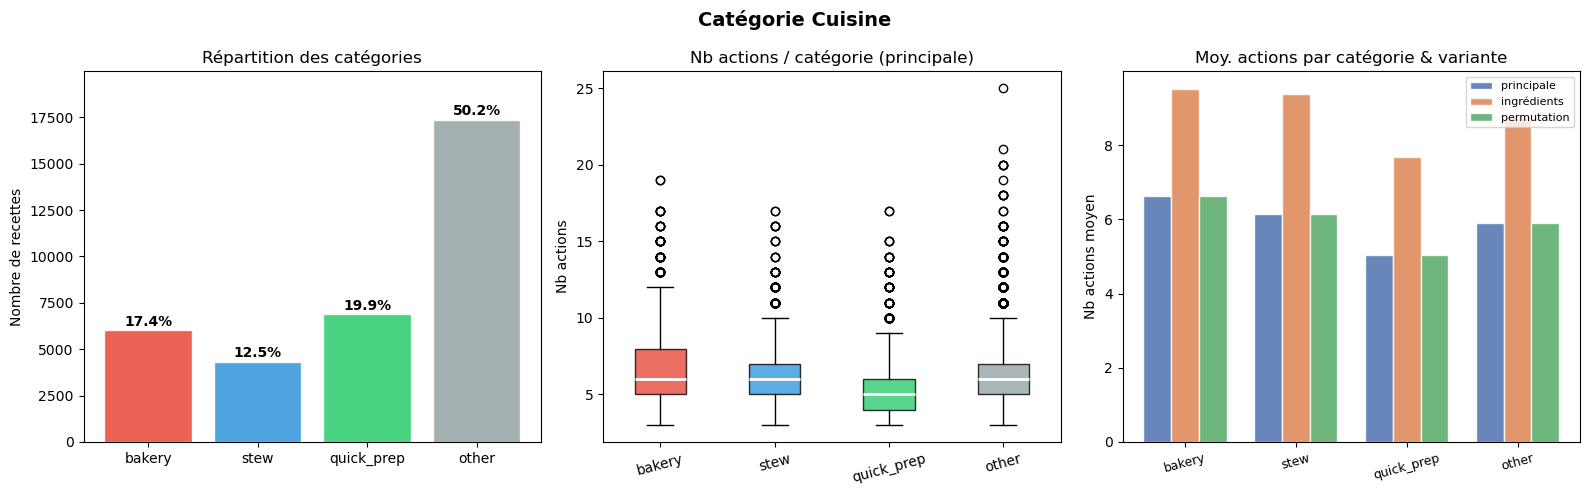

Sauvegardé : img/data_categorie_cuisine.png


In [14]:
import matplotlib.pyplot as plt

CAT_COLORS  = {"bakery": "#e74c3c", "stew": "#3498db", "quick_prep": "#2ecc71", "other": "#95a5a6"}
variantes   = ["nb_principale", "nb_ingredients", "nb_permutation"]
var_labels  = ["principale", "ingrédients", "permutation"]
var_colors  = ["#4C72B0", "#DD8452", "#55A868"]
cat_order   = ["bakery", "stew", "quick_prep", "other"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Catégorie Cuisine", fontsize=14, fontweight="bold")

# Barres répartition + pourcentages
cat_counts = data_wide["category"].value_counts().reindex(cat_order)
bars = axes[0].bar(cat_order, cat_counts.values,
                   color=[CAT_COLORS[c] for c in cat_order],
                   edgecolor="white", alpha=0.88)
for bar, val in zip(bars, cat_counts.values):
    pct = val / len(data_wide) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Nombre de recettes")
axes[0].set_title("Répartition des catégories")
axes[0].set_ylim(0, cat_counts.max() * 1.15)

# Boxplot nb actions par catégorie
data_cat = [data_wide[data_wide["category"] == c]["nb_principale"].values for c in cat_order]
bp = axes[1].boxplot(data_cat, labels=cat_order, patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
for patch, cat in zip(bp["boxes"], cat_order):
    patch.set_facecolor(CAT_COLORS[cat])
    patch.set_alpha(0.8)
axes[1].set_ylabel("Nb actions")
axes[1].set_title("Nb actions / catégorie (principale)")
axes[1].tick_params(axis="x", rotation=15)

# Barres moyennes par catégorie × variante
x = range(len(cat_order))
width = 0.25
for i, (var, label, color) in enumerate(zip(variantes, var_labels, var_colors)):
    means = [data_wide[data_wide["category"] == c][var].mean() for c in cat_order]
    offset = (i - 1) * width
    axes[2].bar([xi + offset for xi in x], means, width,
                label=label, color=color, alpha=0.85, edgecolor="white")
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(cat_order, rotation=15, fontsize=9)
axes[2].set_ylabel("Nb actions moyen")
axes[2].set_title("Moy. actions par catégorie & variante")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("img/data_categorie_cuisine.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : img/data_categorie_cuisine.png")

### Graphiques — Complexité

/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_96550/3527095174.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(data_cplx, labels=cplx_order, patch_artist=True,


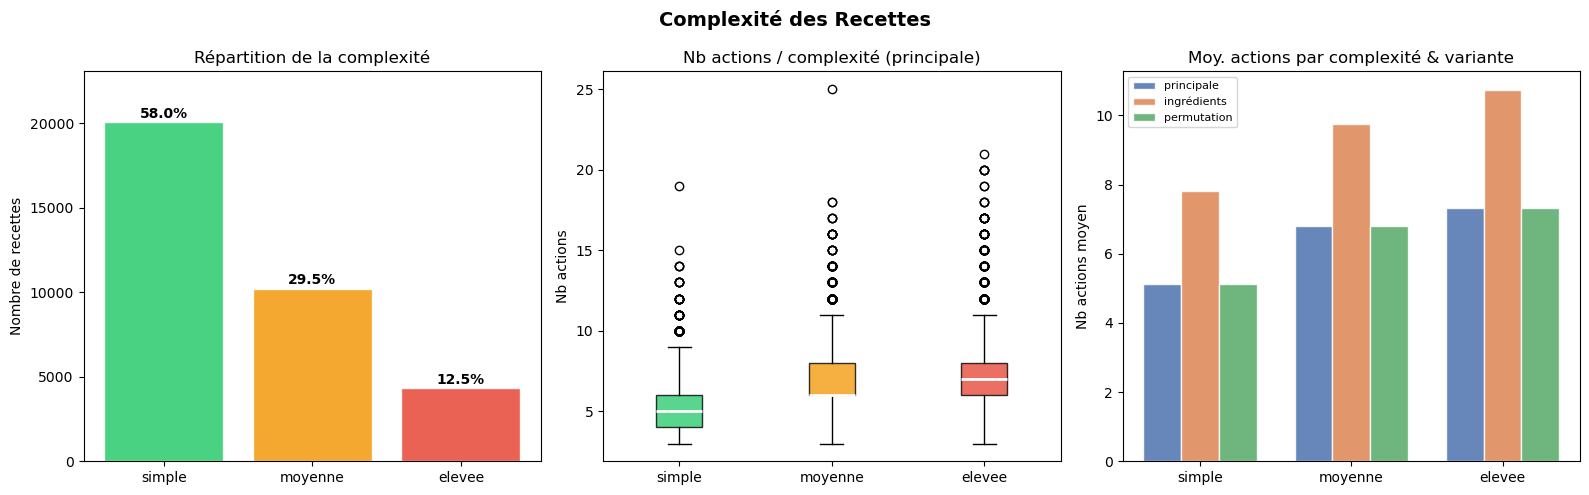

Sauvegardé : img/data_complexite_recettes.png


In [15]:
CPLX_COLORS = {"simple": "#2ecc71", "moyenne": "#f39c12", "elevee": "#e74c3c"}
cplx_order  = ["simple", "moyenne", "elevee"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Complexité des Recettes", fontsize=14, fontweight="bold")

# Barres répartition + pourcentages
cplx_counts = data_wide["complexity"].value_counts().reindex(cplx_order)
bars = axes[0].bar(cplx_order, cplx_counts.values,
                   color=[CPLX_COLORS[c] for c in cplx_order],
                   edgecolor="white", alpha=0.88)
for bar, val in zip(bars, cplx_counts.values):
    pct = val / len(data_wide) * 100
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 80,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[0].set_ylabel("Nombre de recettes")
axes[0].set_title("Répartition de la complexité")
axes[0].set_ylim(0, cplx_counts.max() * 1.15)

# Boxplot nb actions par complexité
data_cplx = [data_wide[data_wide["complexity"] == c]["nb_principale"].values for c in cplx_order]
bp2 = axes[1].boxplot(data_cplx, labels=cplx_order, patch_artist=True,
                      medianprops=dict(color="white", linewidth=2))
for patch, cplx in zip(bp2["boxes"], cplx_order):
    patch.set_facecolor(CPLX_COLORS[cplx])
    patch.set_alpha(0.8)
axes[1].set_ylabel("Nb actions")
axes[1].set_title("Nb actions / complexité (principale)")

# Barres moyennes par complexité × variante
x2 = range(len(cplx_order))
for i, (var, label, color) in enumerate(zip(variantes, var_labels, var_colors)):
    means = [data_wide[data_wide["complexity"] == c][var].mean() for c in cplx_order]
    offset = (i - 1) * width
    axes[2].bar([xi + offset for xi in x2], means, width,
                label=label, color=color, alpha=0.85, edgecolor="white")
axes[2].set_xticks(list(x2))
axes[2].set_xticklabels(cplx_order, fontsize=10)
axes[2].set_ylabel("Nb actions moyen")
axes[2].set_title("Moy. actions par complexité & variante")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("img/data_complexite_recettes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sauvegardé : img/data_complexite_recettes.png")

# test de qualité du dataset 

### etape 1 - preparation des donnees pour les operations de comparaison et d'analyse du document de sortie du pipeline 

In [16]:
# chargement des donnees 
new = "data_variantes_flags.csv"
old = "final_dataset_cleaned_with_normalization_only (1).csv"
data_new = pd.read_csv(new)
data_old = pd.read_csv(old) 

In [17]:
# reshape du csv data_variantes_20260318_1758.csv
id_vars = ["id"]
value_vars = {
    "variante_principale":  "variante_principale",
    "variante_ingredients": "variante_ingredients",
    "variante_permutation": "variante_permutation",
}

rows = []
for _, row in data_new.iterrows():
    for col, label in value_vars.items():
        actions = ast.literal_eval(row[col]) if isinstance(row[col], str) else row[col]
        rows.append({"id": row["id"], "type_2": label, "actions": actions})

data_new_long = pd.DataFrame(rows)
data_new_long["nb_actions"] = data_new_long["actions"].apply(len)
print(f"nouveau formatage: {data_new_long.shape}")
print(data_new_long.head(6).to_string())

nouveau formatage: (103773, 4)
           id                type_2                                                                actions  nb_actions
0  165cdd5492   variante_principale                 [sift, heat, beat, chill, shape, bake, cool, mix, dip]           9
1  165cdd5492  variante_ingredients  [sift, measure, heat, beat, chill, shape, bake, cool, mix, dip, pour]          11
2  165cdd5492  variante_permutation                 [heat, sift, beat, shape, chill, bake, mix, cool, dip]           9
3  166b7da000   variante_principale                                               [chop, mix, roll, serve]           4
4  166b7da000  variante_ingredients                         [chop, shred, slice, measure, mix, pour, roll]           7
5  166b7da000  variante_permutation                                               [roll, chop, mix, serve]           4


In [18]:
# jointures informations data_new et data_old, pour les comparaison future. 
# Convertir la colonne actions de string → liste Python - ancien modele 
data_old["actions"] = data_old["actions"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
data_old["nb_actions"] = data_old["actions"].apply(len) 
# gestion des colonnes utiles + renommer pour la jointure
data_old_clean = data_old[["id", "type_2", "actions", "nb_actions"]].copy()
data_old_clean = data_old_clean.rename(columns={
    "actions": "actions_old",
    "nb_actions": "nb_old"
})
# Préparer le nouveau modèle 
data_new_long = data_new_long.rename(columns={
    "actions": "actions_new",
    "nb_actions": "nb_new"
})
# Jointure sur id + type_2
data_compare = data_new_long.merge(data_old_clean, on=["id", "type_2"], how="inner")
# affichage esquisse 
print(f"Nouveau modèle (long)  : {data_new_long.shape[0]} lignes")
print(f"Ancien modèle          : {data_old_clean.shape[0]} lignes")
print(f"Après jointure (inner) : {data_compare.shape[0]} lignes")
print()
print(data_compare[["id", "type_2", "actions_new", "actions_old", "nb_new", "nb_old"]].head(6).to_string())

Nouveau modèle (long)  : 103773 lignes
Ancien modèle          : 2749491 lignes
Après jointure (inner) : 102144 lignes

           id                type_2                                                            actions_new                                                                     actions_old  nb_new  nb_old
0  165cdd5492   variante_principale                 [sift, heat, beat, chill, shape, bake, cool, mix, dip]  [sift, heat, melt, cool, beat, add, chill, shape, place, bake, cool, mix, dip]       9      13
1  165cdd5492  variante_ingredients  [sift, measure, heat, beat, chill, shape, bake, cool, mix, dip, pour]              [sift, melt, beat, add, chill, shape, place, bake, cool, mix, dip]      11      11
2  166b7da000   variante_principale                                               [chop, mix, roll, serve]                                                                     [mix, roll]       4       2
3  166b7da000  variante_ingredients                         [chop, sh

In [19]:
print(data_compare["type_2"].value_counts()) 

type_2
variante_permutation    36134
variante_principale     34572
variante_ingredients    31438
Name: count, dtype: int64


### test 1 : Verification de la taille des sequences d'action 

TEST 1 — TAILLE DES SÉQUENCES
Total graphes analysés : 103,773

[variante_principale]
  Moyenne : 5.89  |  Médiane : 6.0  |  Min : 3  |  Max : 25

[variante_ingredients]
  Moyenne : 8.75  |  Médiane : 8.0  |  Min : 4  |  Max : 27

[variante_permutation]
  Moyenne : 5.89  |  Médiane : 6.0  |  Min : 3  |  Max : 25

Distribution des flags :
  CONFORME                  103,773  (100.00%)


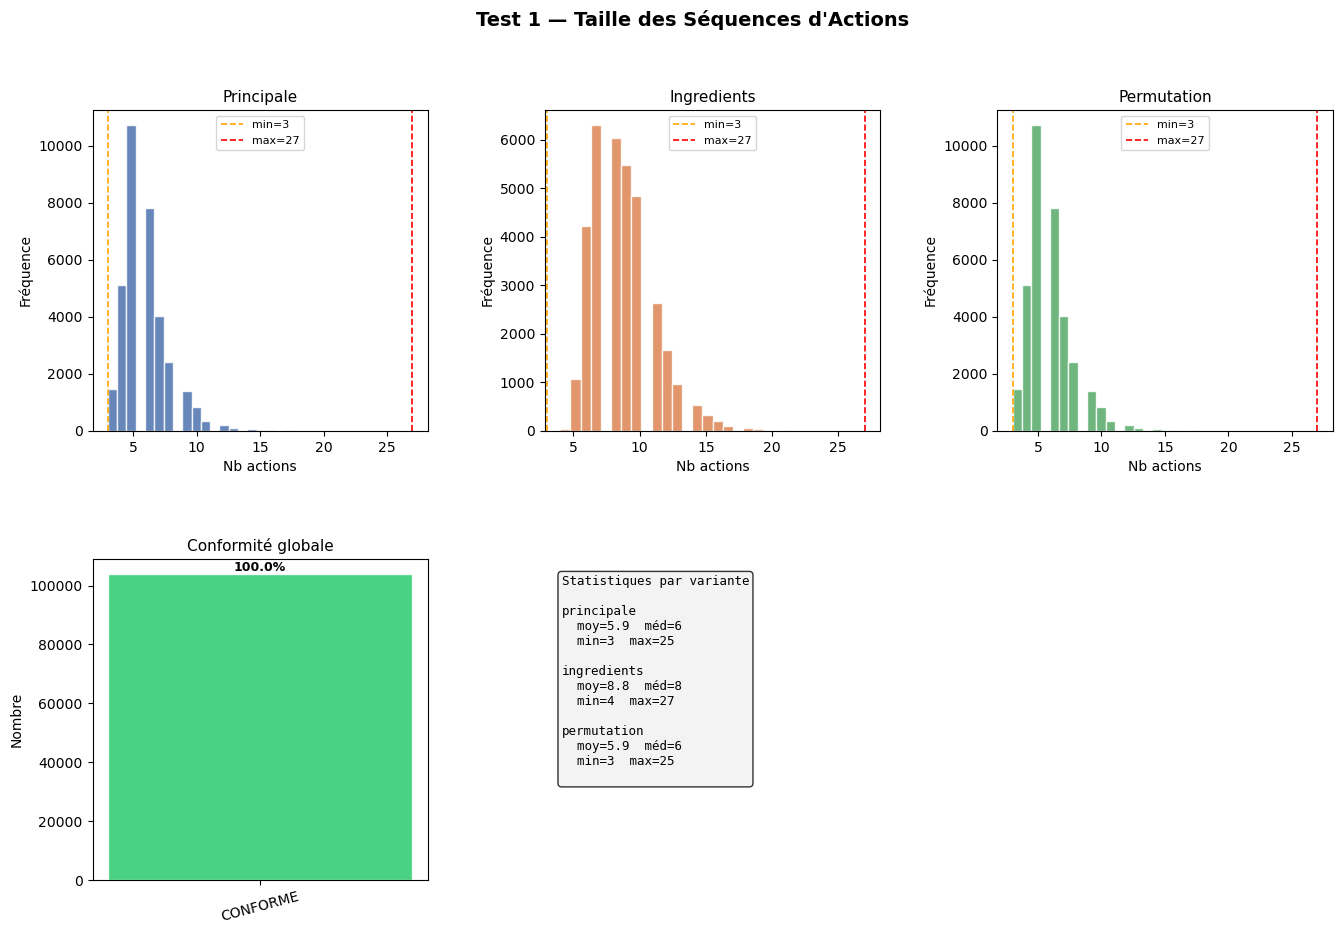


Graphique sauvegardé : test1_taille_sequences.png


In [20]:
# seuil  d'analyse des sequences d'actions: 
MIN_ACTIONS = 3
MAX_ACTIONS = 27

def flag_taille(n):
    if n == 0:        return "FLAG_VIDE"
    elif n < MIN_ACTIONS: return "FLAG_TROP_COURT"
    elif n > MAX_ACTIONS: return "FLAG_TROP_LONG"
    else:             return "CONFORME"

data_new_long["flag_t1"] = data_new_long["nb_new"].apply(flag_taille)

print("=" * 60)
print("TEST 1 — TAILLE DES SÉQUENCES")
print("=" * 60)
print(f"Total graphes analysés : {len(data_new_long):,}")
print()

for variante in ["variante_principale", "variante_ingredients", "variante_permutation"]:
    sub = data_new_long[data_new_long["type_2"] == variante]["nb_new"]
    print(f"[{variante}]")
    print(f"  Moyenne : {sub.mean():.2f}  |  Médiane : {sub.median():.1f}  |  Min : {sub.min()}  |  Max : {sub.max()}")
    print()

print("Distribution des flags :")
flag_counts = data_new_long["flag_t1"].value_counts()
for flag, count in flag_counts.items():
    pct = count / len(data_new_long) * 100
    print(f"  {flag:<25} {count:>6,}  ({pct:.2f}%)")

variantes  = ["variante_principale", "variante_ingredients", "variante_permutation"]
colors     = ["#4C72B0", "#DD8452", "#55A868"]
flag_colors = {"CONFORME": "#2ecc71", "FLAG_TROP_COURT": "#e67e22",
               "FLAG_TROP_LONG": "#e74c3c", "FLAG_VIDE": "#8e44ad"}

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Test 1 — Taille des Séquences d'Actions", fontsize=14, fontweight="bold")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# Ligne 1 : histogramme par variante
for i, (variante, color) in enumerate(zip(variantes, colors)):
    ax = fig.add_subplot(gs[0, i])
    data = data_new_long[data_new_long["type_2"] == variante]["nb_new"]
    ax.hist(data, bins=30, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(MIN_ACTIONS, color="orange", linestyle="--", linewidth=1.2, label=f"min={MIN_ACTIONS}")
    ax.axvline(MAX_ACTIONS, color="red",    linestyle="--", linewidth=1.2, label=f"max={MAX_ACTIONS}")
    ax.set_title(variante.replace("variante_", "").replace("_", " ").title(), fontsize=11)
    ax.set_xlabel("Nb actions")
    ax.set_ylabel("Fréquence")
    ax.legend(fontsize=8)

# Ligne 2 col 0 : barres conformité globale + pourcentages
ax_bar_global = fig.add_subplot(gs[1, 0])
flag_global   = data_new_long["flag_t1"].value_counts()
bar_colors_g  = [flag_colors.get(f, "#95a5a6") for f in flag_global.index]
bars_g = ax_bar_global.bar(flag_global.index, flag_global.values,
                            color=bar_colors_g, edgecolor="white", alpha=0.88)
for bar, val in zip(bars_g, flag_global.values):
    pct = val / len(data_new_long) * 100
    ax_bar_global.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                       f"{pct:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax_bar_global.set_title("Conformité globale", fontsize=11)
ax_bar_global.set_ylabel("Nombre")
ax_bar_global.tick_params(axis="x", rotation=15)

# Ligne 2 col 1 : stats texte
ax_stats = fig.add_subplot(gs[1, 1])
ax_stats.axis("off")
lines = ["Statistiques par variante\n"]
for variante in variantes:
    sub   = data_new_long[data_new_long["type_2"] == variante]["nb_new"]
    label = variante.replace("variante_", "")
    lines.append(f"{label}\n  moy={sub.mean():.1f}  méd={sub.median():.0f}\n  min={sub.min()}  max={sub.max()}\n")
ax_stats.text(0.05, 0.95, "\n".join(lines), transform=ax_stats.transAxes,
              fontsize=9, verticalalignment="top", fontfamily="monospace",
              bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))

plt.savefig("img/test1_taille_sequences.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nGraphique sauvegardé : test1_taille_sequences.png")

### Test 2 — Ratio Variante Principale vs Nb Steps Réels

TEST 2 — RATIO NB ACTIONS / NB STEPS RÉELS
Recettes analysées : 34,591
Ratio moyen        : 1.034
Ratio médian       : 0.700
Ratio min          : 0.031
Ratio max          : 10.000

Distribution des flags :
  CONFORME             27,764  (80.26%)
  RATIO_FAIBLE          3,667  (10.60%)
  RATIO_ELEVE           3,160  (9.14%)

Ratio moyen par complexité :
  [simple]  n=20,062  moy=1.483  méd=1.000
  [moyenne]  n=10,213  moy=0.477  méd=0.455
  [elevee]  n=4,316  moy=0.267  méd=0.250


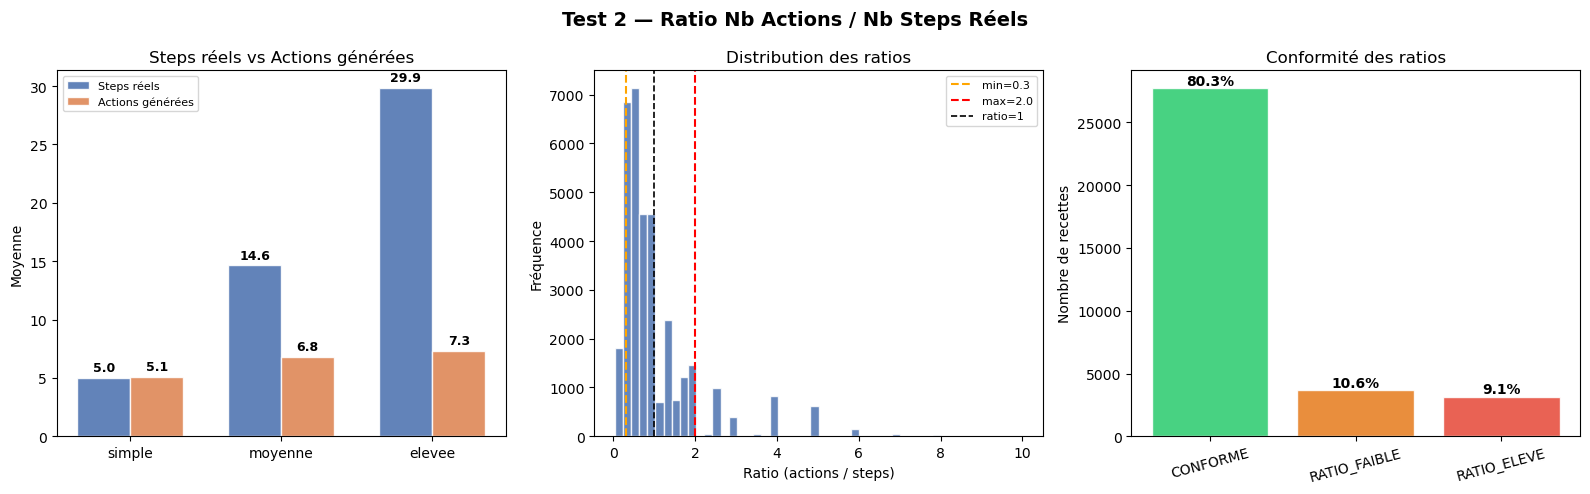

Graphique sauvegardé : img/test2_ratio_steps.png


In [ ]:
# ── Préparer les données : variante_principale + nb_steps réels ──────────────
df_t2 = data_new_long[data_new_long["type_2"] == "variante_principale"].copy()

# Charger nb_steps + complexity depuis recipes.csv (indépendant de data_wide)
df_steps = pd.read_csv("recipes.csv")[["id", "number_of_steps"]]
df_steps["complexity"] = df_steps["number_of_steps"].apply(
    lambda n: "simple" if pd.isna(n) or n <= 10 else ("moyenne" if n <= 20 else "elevee")
)

df_t2 = df_t2.merge(df_steps, on="id", how="left")
df_t2 = df_t2.dropna(subset=["number_of_steps"])
df_t2["number_of_steps"] = df_t2["number_of_steps"].astype(int)

# ── Calcul du ratio
df_t2["ratio"] = df_t2["nb_new"] / df_t2["number_of_steps"]

# ── Flags
RATIO_MIN = 0.3
RATIO_MAX = 2.0

def flag_ratio(r):
    if r < RATIO_MIN:  return "RATIO_FAIBLE"
    elif r > RATIO_MAX: return "RATIO_ELEVE"
    else:               return "CONFORME"

df_t2["flag_t2"] = df_t2["ratio"].apply(flag_ratio)

# ── Statistiques 
print("=" * 60)
print("TEST 2 — RATIO NB ACTIONS / NB STEPS RÉELS")
print("=" * 60)
print(f"Recettes analysées : {len(df_t2):,}")
print(f"Ratio moyen        : {df_t2['ratio'].mean():.3f}")
print(f"Ratio médian       : {df_t2['ratio'].median():.3f}")
print(f"Ratio min          : {df_t2['ratio'].min():.3f}")
print(f"Ratio max          : {df_t2['ratio'].max():.3f}")
print()

print("Distribution des flags :")
for flag, count in df_t2["flag_t2"].value_counts().items():
    pct = count / len(df_t2) * 100
    print(f"  {flag:<20} {count:>6,}  ({pct:.2f}%)")
print()

print("Ratio moyen par complexité :")
for cplx in ["simple", "moyenne", "elevee"]:
    sub = df_t2[df_t2["complexity"] == cplx]["ratio"]
    print(f"  [{cplx}]  n={len(sub):,}  moy={sub.mean():.3f}  méd={sub.median():.3f}")

# ── Graphiques 
CPLX_COLORS = {"simple": "#2ecc71", "moyenne": "#f39c12", "elevee": "#e74c3c"}
cplx_order  = ["simple", "moyenne", "elevee"]
flag_colors = {"CONFORME": "#2ecc71", "RATIO_FAIBLE": "#e67e22", "RATIO_ELEVE": "#e74c3c"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test 2 — Ratio Nb Actions / Nb Steps Réels", fontsize=14, fontweight="bold")

# Col 0 : barres groupées — steps réels vs actions générées par complexité
x = np.arange(len(cplx_order))
width = 0.35
mean_steps   = [df_t2[df_t2["complexity"] == c]["number_of_steps"].mean() for c in cplx_order]
mean_actions = [df_t2[df_t2["complexity"] == c]["nb_new"].mean() for c in cplx_order]

bars1 = axes[0].bar(x - width/2, mean_steps,   width, label="Steps réels",       color="#4C72B0", edgecolor="white", alpha=0.88)
bars2 = axes[0].bar(x + width/2, mean_actions, width, label="Actions générées",  color="#DD8452", edgecolor="white", alpha=0.88)
for bar, val in zip(bars1, mean_steps):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(bars2, mean_actions):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cplx_order, fontsize=10)
axes[0].set_ylabel("Moyenne")
axes[0].set_title("Steps réels vs Actions générées")
axes[0].legend(fontsize=8)

# Col 1 : histogramme de la distribution des ratios
axes[1].hist(df_t2["ratio"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].axvline(RATIO_MIN, color="orange", linestyle="--", linewidth=1.5, label=f"min={RATIO_MIN}")
axes[1].axvline(RATIO_MAX, color="red",    linestyle="--", linewidth=1.5, label=f"max={RATIO_MAX}")
axes[1].axvline(1.0,       color="black",  linestyle="--", linewidth=1.2, label="ratio=1")
axes[1].set_xlabel("Ratio (actions / steps)")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Distribution des ratios")
axes[1].legend(fontsize=8)

# Col 2 : barres flags + pourcentages
flag_counts  = df_t2["flag_t2"].value_counts()
bar_colors_f = [flag_colors.get(f, "#95a5a6") for f in flag_counts.index]
bars_f = axes[2].bar(flag_counts.index, flag_counts.values,
                     color=bar_colors_f, edgecolor="white", alpha=0.88)
for bar, val in zip(bars_f, flag_counts.values):
    pct = val / len(df_t2) * 100
    axes[2].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
                 f"{pct:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[2].set_title("Conformité des ratios")
axes[2].set_ylabel("Nombre de recettes")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("img/test2_ratio_steps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/test2_ratio_steps.png")

---
## Test 3 — Validation Variante Ingrédients (Delta & Jaccard)

In [ ]:
# ── Test 3 : Delta et Jaccard — variante_ingredients vs variante_principale ──
df_t3 = data_wide[["id", "nb_principale", "nb_ingredients",
                    "actions_principale", "actions_ingredients", "category", "complexity"]].copy()

# Delta = nb_ingredients - nb_principale
df_t3["delta"] = df_t3["nb_ingredients"] - df_t3["nb_principale"]

# Jaccard : similarité entre les deux ensembles d'actions
def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb: return 1.0
    if not sa or not sb:  return 0.0
    return len(sa & sb) / len(sa | sb)

df_t3["jaccard"] = df_t3.apply(
    lambda r: jaccard(r["actions_principale"], r["actions_ingredients"]), axis=1)

# Flags
def flag_delta(row):
    if row["nb_ingredients"] < row["nb_principale"]:
        return "FLAG_MOINS_ACTIONS"
    elif row["delta"] == 0:
        return "FLAG_AUCUN_AJOUT"
    elif row["delta"] > 10:
        return "FLAG_TROP_AJOUT"
    else:
        return "CONFORME"

df_t3["flag_t3"] = df_t3.apply(flag_delta, axis=1)

# Gestes ajoutés (verbes dans ingrédients absents de principale)
df_t3["gestes_ajoutes"] = df_t3.apply(
    lambda r: len(set(r["actions_ingredients"]) - set(r["actions_principale"])), axis=1)

# ── Statistiques 
print("=" * 60)
print("TEST 3 — DELTA & JACCARD VARIANTE INGRÉDIENTS")
print("=" * 60)
print(f"Total paires analysées : {len(df_t3):,}")
print(f"Delta moyen   : {df_t3['delta'].mean():.2f}  |  médian : {df_t3['delta'].median():.1f}")
print(f"Delta min/max : {df_t3['delta'].min()} / {df_t3['delta'].max()}")
print(f"Jaccard moyen : {df_t3['jaccard'].mean():.3f}")
print(f"Gestes ajoutés (moy) : {df_t3['gestes_ajoutes'].mean():.2f}  |  méd : {df_t3['gestes_ajoutes'].median():.1f}")
print()

print("Distribution des flags :")
for flag, count in df_t3["flag_t3"].value_counts().items():
    pct = count / len(df_t3) * 100
    print(f"  {flag:<25} {count:>6,}  ({pct:.2f}%)")

print()
print("Par complexité :")
for cplx in ["simple", "moyenne", "elevee"]:
    sub = df_t3[df_t3["complexity"] == cplx]
    print(f"  [{cplx}]  n={len(sub):,}  delta_moy={sub['delta'].mean():.2f}  jaccard_moy={sub['jaccard'].mean():.3f}")

print()
print("Par catégorie :")
for cat in ["bakery", "stew", "quick_prep", "other"]:
    sub = df_t3[df_t3["category"] == cat]
    print(f"  [{cat}]  n={len(sub):,}  delta_moy={sub['delta'].mean():.2f}  jaccard_moy={sub['jaccard'].mean():.3f}")

TEST 3 — DELTA & JACCARD VARIANTE INGRÉDIENTS
Total paires analysées : 34,591
Delta moyen   : 2.87  |  médian : 3.0
Delta min/max : 0 / 11
Jaccard moyen : 0.397
Gestes ajoutés (moy) : 4.62  |  méd : 4.0

Distribution des flags :
  CONFORME                  34,363  (99.34%)
  FLAG_AUCUN_AJOUT             227  (0.66%)
  FLAG_TROP_AJOUT                1  (0.00%)

Par complexité :
  [simple]  n=20,062  delta_moy=2.71  jaccard_moy=0.379
  [moyenne]  n=10,213  delta_moy=2.95  jaccard_moy=0.424
  [elevee]  n=4,316  delta_moy=3.42  jaccard_moy=0.420

Par catégorie :
  [bakery]  n=6,027  delta_moy=2.89  jaccard_moy=0.420
  [stew]  n=4,316  delta_moy=3.23  jaccard_moy=0.401
  [quick_prep]  n=6,879  delta_moy=2.66  jaccard_moy=0.357
  [other]  n=17,369  delta_moy=2.85  jaccard_moy=0.404


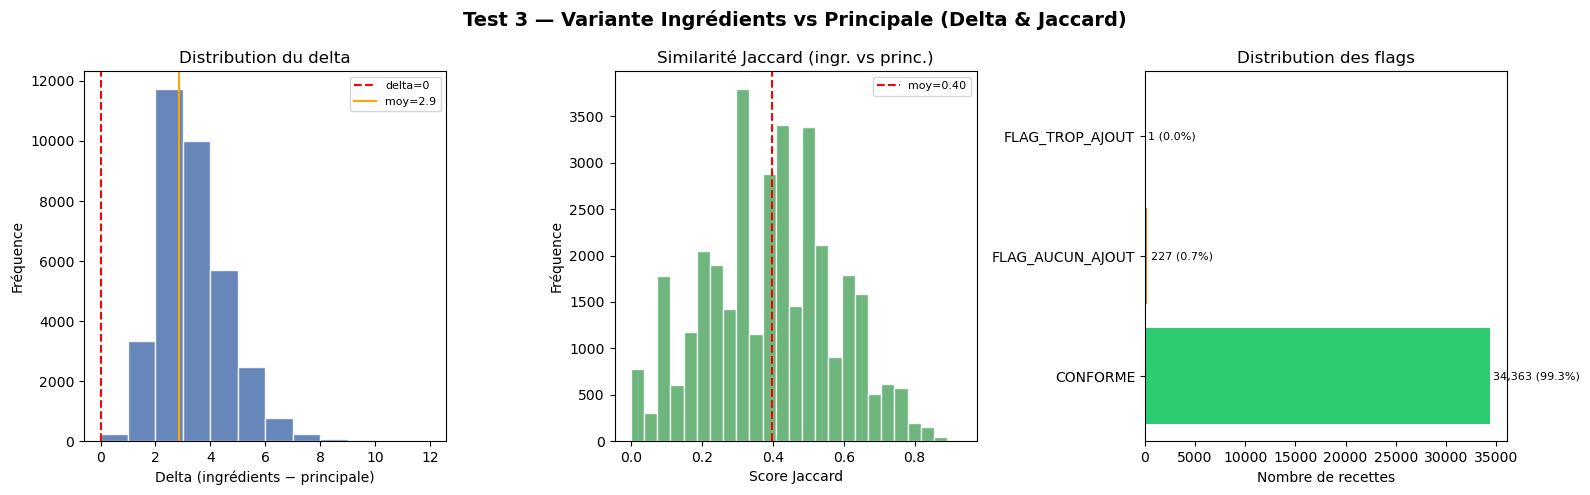

Graphique sauvegardé : img/test3_delta_jaccard.png


In [ ]:
# ── Graphiques Test 3 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test 3 — Variante Ingrédients vs Principale (Delta & Jaccard)", fontsize=14, fontweight="bold")

# Col 0 : Distribution du delta
axes[0].hist(df_t3["delta"], bins=range(df_t3["delta"].min(), df_t3["delta"].max() + 2),
             color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="delta=0")
axes[0].axvline(df_t3["delta"].mean(), color="orange", linestyle="-", linewidth=1.5,
                label=f"moy={df_t3['delta'].mean():.1f}")
axes[0].set_xlabel("Delta (ingrédients − principale)")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distribution du delta")
axes[0].legend(fontsize=8)

# Col 1 : Distribution Jaccard
axes[1].hist(df_t3["jaccard"], bins=25, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(df_t3["jaccard"].mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"moy={df_t3['jaccard'].mean():.2f}")
axes[1].set_xlabel("Score Jaccard")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Similarité Jaccard (ingr. vs princ.)")
axes[1].legend(fontsize=8)

# Col 2 : Flags — barres horizontales
flag_counts_t3 = df_t3["flag_t3"].value_counts()
colors_t3 = {"CONFORME": "#2ecc71", "FLAG_MOINS_ACTIONS": "#e74c3c",
             "FLAG_AUCUN_AJOUT": "#e67e22", "FLAG_TROP_AJOUT": "#f39c12"}
bars = axes[2].barh(flag_counts_t3.index, flag_counts_t3.values,
                    color=[colors_t3.get(f, "#95a5a6") for f in flag_counts_t3.index])
for i, (flag, count) in enumerate(zip(flag_counts_t3.index, flag_counts_t3.values)):
    axes[2].text(count + len(df_t3) * 0.01, i,
                 f"{count:,} ({count / len(df_t3) * 100:.1f}%)", va="center", fontsize=8)
axes[2].set_title("Distribution des flags")
axes[2].set_xlabel("Nombre de recettes")

plt.tight_layout()
plt.savefig("img/test3_delta_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/test3_delta_jaccard.png")

---
## Test 4A — Overlap + Distance Levenshtein (Variante Permutation)

In [ ]:
# ── Test 4A : Overlap et Levenshtein — variante_permutation vs variante_principale ──

def overlap(a, b):
    """Fraction de a présente dans b (ordre-insensible)"""
    if not a: return 0.0
    return len(set(a) & set(b)) / len(set(a))

def levenshtein(a, b):
    """Distance d'édition (ordre-sensible)"""
    m, n = len(a), len(b)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1): dp[i][0] = i
    for j in range(n + 1): dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if a[i-1] == b[j-1]: dp[i][j] = dp[i-1][j-1]
            else: dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[m][n]

def levenshtein_norm(a, b):
    dist = levenshtein(a, b)
    max_len = max(len(a), len(b))
    return dist / max_len if max_len > 0 else 0.0

df_t4a = data_wide[["id", "actions_principale", "actions_permutation"]].copy()
df_t4a = df_t4a[(df_t4a["actions_principale"].apply(len) > 0) &
                (df_t4a["actions_permutation"].apply(len) > 0)]

df_t4a["overlap_perm"]  = df_t4a.apply(lambda r: overlap(r["actions_principale"], r["actions_permutation"]), axis=1)
df_t4a["lev_dist"]      = df_t4a.apply(lambda r: levenshtein(r["actions_principale"], r["actions_permutation"]), axis=1)
df_t4a["lev_dist_norm"] = df_t4a.apply(lambda r: levenshtein_norm(r["actions_principale"], r["actions_permutation"]), axis=1)

def flag_perm(ov):
    if ov == 1.0:   return "FLAG_IDENTIQUE"
    elif ov >= 0.6: return "CONFORME"
    else:           return "FLAG_SIMILARITE_BASSE"

df_t4a["flag_t4a"] = df_t4a["overlap_perm"].apply(flag_perm)

# ── Statistiques
print("=" * 60)
print("TEST 4A — PERMUTATION OVERLAP & LEVENSHTEIN")
print("=" * 60)
print(f"Total permutations analysées : {len(df_t4a):,}")
print(f"Overlap moyen   : {df_t4a['overlap_perm'].mean():.3f}")
print(f"Lev. dist brute (moy)  : {df_t4a['lev_dist'].mean():.2f}  |  méd : {df_t4a['lev_dist'].median():.1f}")
print(f"Lev. dist norm  (moy)  : {df_t4a['lev_dist_norm'].mean():.3f}")
print()

print("Distribution des flags :")
for flag, count in df_t4a["flag_t4a"].value_counts().items():
    pct = count / len(df_t4a) * 100
    print(f"  {flag:<30} {count:>6,}  ({pct:.2f}%)")

print("\nDistribution distances Levenshtein :")
for dist_val in sorted(df_t4a["lev_dist"].unique()[:10]):
    count = (df_t4a["lev_dist"] == dist_val).sum()
    pct = count / len(df_t4a) * 100
    print(f"  dist={dist_val}  →  {count:,}  ({pct:.1f}%)")

TEST 4A — PERMUTATION OVERLAP & LEVENSHTEIN
Total permutations analysées : 34,591
Overlap moyen   : 1.000
Lev. dist brute (moy)  : 2.86  |  méd : 2.0
Lev. dist norm  (moy)  : 0.501

Distribution des flags :
  FLAG_IDENTIQUE                 34,591  (100.00%)

Distribution distances Levenshtein :
  dist=2  →  18,696  (54.0%)
  dist=3  →  4,474  (12.9%)
  dist=4  →  9,943  (28.7%)
  dist=5  →  707  (2.0%)
  dist=6  →  655  (1.9%)
  dist=7  →  64  (0.2%)
  dist=8  →  45  (0.1%)
  dist=9  →  3  (0.0%)
  dist=10  →  3  (0.0%)
  dist=11  →  1  (0.0%)


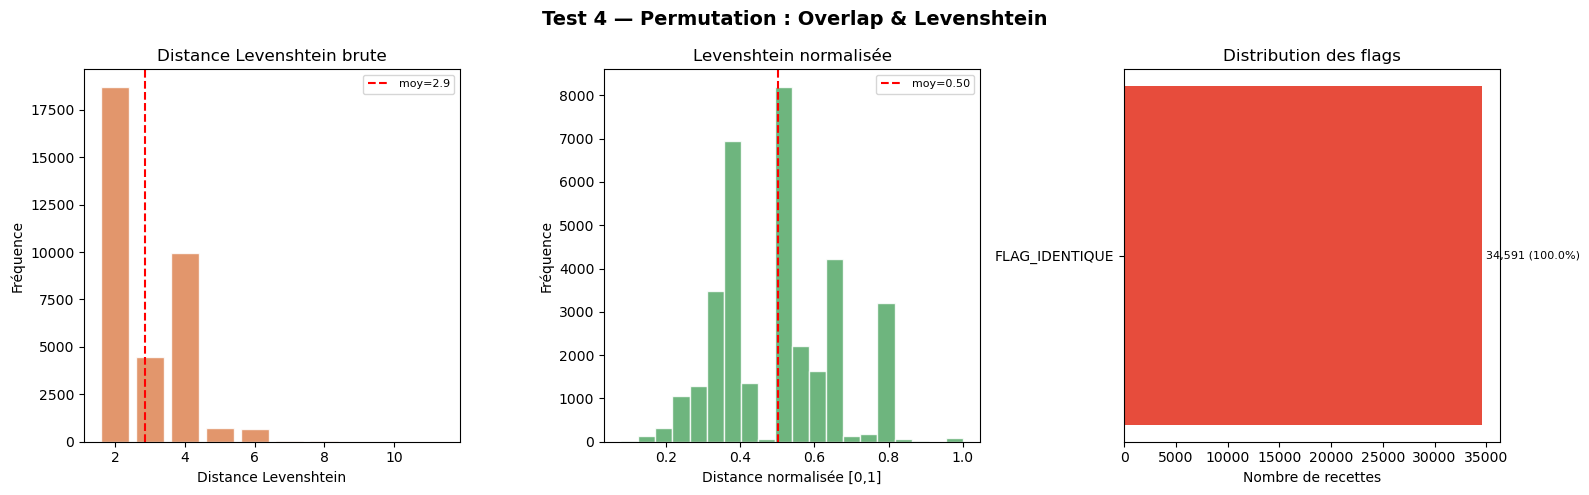

Graphique sauvegardé : img/test4-overlap_levenshtein.png


In [ ]:
# ── Graphiques Test 4 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test 4 — Permutation : Overlap & Levenshtein", fontsize=14, fontweight="bold")

# Col 0 : Distance Levenshtein brute
lev_counts = df_t4a["lev_dist"].value_counts().sort_index()
axes[0].bar(lev_counts.index[:15], lev_counts.values[:15], color="#DD8452", edgecolor="white", alpha=0.85)
axes[0].axvline(df_t4a["lev_dist"].mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"moy={df_t4a['lev_dist'].mean():.1f}")
axes[0].set_xlabel("Distance Levenshtein")
axes[0].set_ylabel("Fréquence")
axes[0].set_title("Distance Levenshtein brute")
axes[0].legend(fontsize=8)

# Col 1 : Distance Levenshtein normalisée
axes[1].hist(df_t4a["lev_dist_norm"], bins=20, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(df_t4a["lev_dist_norm"].mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"moy={df_t4a['lev_dist_norm'].mean():.2f}")
axes[1].set_xlabel("Distance normalisée [0,1]")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Levenshtein normalisée")
axes[1].legend(fontsize=8)

# Col 2 : Flags
flag_counts_t4a = df_t4a["flag_t4a"].value_counts()
colors_t4a = {"CONFORME": "#2ecc71", "FLAG_IDENTIQUE": "#e74c3c", "FLAG_SIMILARITE_BASSE": "#e67e22"}
bars = axes[2].barh(flag_counts_t4a.index, flag_counts_t4a.values,
                    color=[colors_t4a.get(f, "#95a5a6") for f in flag_counts_t4a.index])
for i, (flag, count) in enumerate(zip(flag_counts_t4a.index, flag_counts_t4a.values)):
    axes[2].text(count + len(df_t4a) * 0.01, i,
                 f"{count:,} ({count / len(df_t4a) * 100:.1f}%)", va="center", fontsize=8)
axes[2].set_title("Distribution des flags")
axes[2].set_xlabel("Nombre de recettes")

plt.tight_layout()
plt.savefig("img/test4-overlap_levenshtein.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/test4-overlap_levenshtein.png")

---
## Test 5 — Comparaison Ancien Modèle vs Nouveau Modèle

In [ ]:
# ── Test 5 : Comparaison ancien vs nouveau modèle (variante_principale) ──────
df_t5 = data_compare[data_compare["type_2"] == "variante_principale"][["id", "nb_new", "nb_old"]].copy()

df_t5["ratio_new_old"] = df_t5.apply(
    lambda r: r["nb_new"] / r["nb_old"] if r["nb_old"] > 0 else np.nan, axis=1)

def flag_compare(row):
    if row["nb_new"] < row["nb_old"] * 0.5:  return "FLAG_REDUIT_SIGNIFICATIF"
    elif row["nb_new"] > row["nb_old"] * 2:   return "FLAG_AUGMENTE_SIGNIFICATIF"
    else:                                     return "CONFORME"

df_t5["flag_t5"] = df_t5.apply(flag_compare, axis=1)

# ── Statistiques 
print("=" * 60)
print("TEST 5 — COMPARAISON ANCIEN vs NOUVEAU MODÈLE")
print("=" * 60)
print(f"Recettes communes analysées : {len(df_t5):,}")
print()
print(f"Ancien modèle  → nb actions moy : {df_t5['nb_old'].mean():.2f}  méd : {df_t5['nb_old'].median():.1f}")
print(f"Nouveau modèle → nb actions moy : {df_t5['nb_new'].mean():.2f}  méd : {df_t5['nb_new'].median():.1f}")
print(f"Ratio moyen (nouveau/ancien) : {df_t5['ratio_new_old'].mean():.3f}")
print()

print("Distribution des flags :")
for flag, count in df_t5["flag_t5"].value_counts().items():
    pct = count / len(df_t5) * 100
    print(f"  {flag:<35} {count:>6,}  ({pct:.2f}%)")

TEST 5 — COMPARAISON ANCIEN vs NOUVEAU MODÈLE
Recettes communes analysées : 34,572

Ancien modèle  → nb actions moy : 10.07  méd : 9.0
Nouveau modèle → nb actions moy : 5.89  méd : 6.0
Ratio moyen (nouveau/ancien) : 1.136

Distribution des flags :
  CONFORME                            20,601  (59.59%)
  FLAG_REDUIT_SIGNIFICATIF             9,669  (27.97%)
  FLAG_AUGMENTE_SIGNIFICATIF           4,302  (12.44%)


/var/folders/8y/132c5n416hv_xss1v6x1t6jc0000gn/T/ipykernel_96550/2306641034.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot([df_t5["nb_old"].values, df_t5["nb_new"].values],


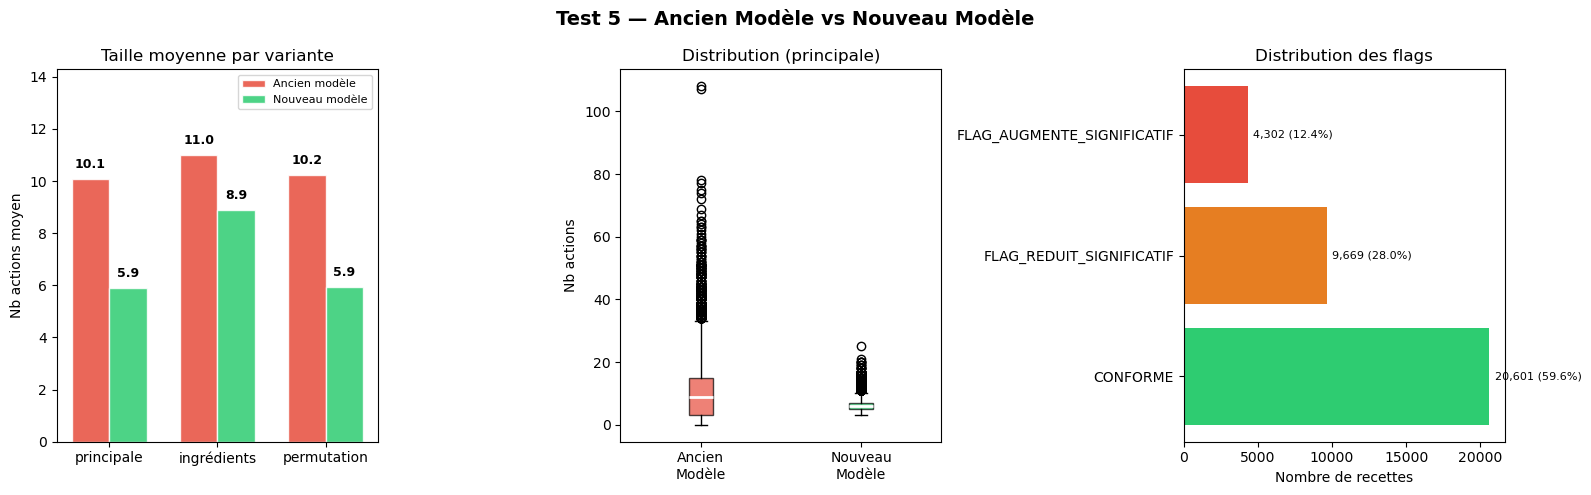

Graphique sauvegardé : img/test5_ancien_vs_nouveau.png


In [ ]:
# ── Graphiques Test 5 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test 5 — Ancien Modèle vs Nouveau Modèle", fontsize=14, fontweight="bold")

# Col 0 : Barres groupées — taille moyenne par variante (ancien vs nouveau)
variantes_t5 = ["variante_principale", "variante_ingredients", "variante_permutation"]
var_labels = ["principale", "ingrédients", "permutation"]
mean_old_v = [data_compare[data_compare["type_2"] == v]["nb_old"].mean() for v in variantes_t5]
mean_new_v = [data_compare[data_compare["type_2"] == v]["nb_new"].mean() for v in variantes_t5]
x = np.arange(len(var_labels))
width = 0.35
bars1 = axes[0].bar(x - width/2, mean_old_v, width, label="Ancien modèle", color="#e74c3c", edgecolor="white", alpha=0.85)
bars2 = axes[0].bar(x + width/2, mean_new_v, width, label="Nouveau modèle", color="#2ecc71", edgecolor="white", alpha=0.85)
for bar, val in zip(bars1, mean_old_v):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
for bar, val in zip(bars2, mean_new_v):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{val:.1f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(var_labels, fontsize=10)
axes[0].set_ylabel("Nb actions moyen")
axes[0].set_title("Taille moyenne par variante")
axes[0].set_ylim(0, max(mean_old_v + mean_new_v) * 1.3)
axes[0].legend(fontsize=8)

# Col 1 : Boxplot comparatif (principale)
bp = axes[1].boxplot([df_t5["nb_old"].values, df_t5["nb_new"].values],
                     labels=["Ancien\nModèle", "Nouveau\nModèle"],
                     patch_artist=True,
                     medianprops=dict(color="white", linewidth=2))
bp["boxes"][0].set_facecolor("#e74c3c"); bp["boxes"][0].set_alpha(0.7)
bp["boxes"][1].set_facecolor("#2ecc71"); bp["boxes"][1].set_alpha(0.7)
axes[1].set_ylabel("Nb actions")
axes[1].set_title("Distribution (principale)")

# Col 2 : Flags barres horizontales
flag_counts_t5 = df_t5["flag_t5"].value_counts()
colors_t5 = {"CONFORME": "#2ecc71", "FLAG_REDUIT_SIGNIFICATIF": "#e67e22", "FLAG_AUGMENTE_SIGNIFICATIF": "#e74c3c"}
bars = axes[2].barh(flag_counts_t5.index, flag_counts_t5.values,
                    color=[colors_t5.get(f, "#95a5a6") for f in flag_counts_t5.index])
for i, (flag, count) in enumerate(zip(flag_counts_t5.index, flag_counts_t5.values)):
    axes[2].text(count + len(df_t5) * 0.01, i,
                 f"{count:,} ({count / len(df_t5) * 100:.1f}%)", va="center", fontsize=8)
axes[2].set_title("Distribution des flags")
axes[2].set_xlabel("Nombre de recettes")

plt.tight_layout()
plt.savefig("img/test5_ancien_vs_nouveau.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/test5_ancien_vs_nouveau.png")

In [ ]:
# ── Test 5b : Vocabulaire d'actions + Jaccard/Delta ancien vs nouveau ────────
from collections import Counter

# Filtrer variante_principale pour la comparaison
df_t5b = data_compare[data_compare["type_2"] == "variante_principale"].copy()

# ── Vocabulaire 
all_verbs_old = [v for actions in df_t5b["actions_old"] for v in actions]
all_verbs_new = [v for actions in df_t5b["actions_new"] for v in actions]

vocab_old = set(all_verbs_old)
vocab_new = set(all_verbs_new)
vocab_commun = vocab_old & vocab_new

top_old = Counter(all_verbs_old).most_common(15)
top_new = Counter(all_verbs_new).most_common(15)

print("=" * 60)
print("TEST 5b — VOCABULAIRE D'ACTIONS")
print("=" * 60)
print(f"Verbes uniques ancien modèle  : {len(vocab_old)}")
print(f"Verbes uniques nouveau modèle : {len(vocab_new)}")
print(f"Verbes en commun              : {len(vocab_commun)}")
print(f"Verbes exclusifs ancien       : {len(vocab_old - vocab_new)}")
print(f"Verbes exclusifs nouveau      : {len(vocab_new - vocab_old)}")
print()

print("Top 15 verbes — Ancien modèle :")
for verb, count in top_old:
    print(f"  {verb:<20} {count:>6,}")
print()
print("Top 15 verbes — Nouveau modèle :")
for verb, count in top_new:
    print(f"  {verb:<20} {count:>6,}")

# ── Jaccard et Delta ancien vs nouveau (par recette)
def jaccard(a, b):
    sa, sb = set(a), set(b)
    if not sa and not sb: return 1.0
    if not sa or not sb:  return 0.0
    return len(sa & sb) / len(sa | sb)

df_t5b["jaccard_old_new"] = df_t5b.apply(
    lambda r: jaccard(r["actions_old"], r["actions_new"]), axis=1)
df_t5b["delta_old_new"] = df_t5b["nb_new"] - df_t5b["nb_old"]

print()
print("=" * 60)
print("JACCARD & DELTA — ANCIEN vs NOUVEAU (par recette)")
print("=" * 60)
print(f"Jaccard moyen  : {df_t5b['jaccard_old_new'].mean():.3f}")
print(f"Jaccard médian : {df_t5b['jaccard_old_new'].median():.3f}")
print(f"Delta moyen    : {df_t5b['delta_old_new'].mean():.2f}")
print(f"Delta médian   : {df_t5b['delta_old_new'].median():.1f}")

TEST 5b — VOCABULAIRE D'ACTIONS
Verbes uniques ancien modèle  : 345
Verbes uniques nouveau modèle : 674
Verbes en commun              : 285
Verbes exclusifs ancien       : 60
Verbes exclusifs nouveau      : 389

Top 15 verbes — Ancien modèle :
  add                  28,968
  mix                  24,754
  place                16,299
  stir                 15,761
  cook                 11,815
  bake                 11,055
  heat                  9,836
  cut                   9,633
  remove                9,141
  sprinkle              8,546
  serve                 8,504
  pour                  7,839
  drain                 7,075
  cool                  6,827
  preheat               5,907

Top 15 verbes — Nouveau modèle :
  serve                29,479
  mix                  24,108
  chop                 21,624
  heat                 15,220
  bake                  8,642
  stir                  6,628
  cook                  6,014
  pour                  6,005
  toss                  3,483
  

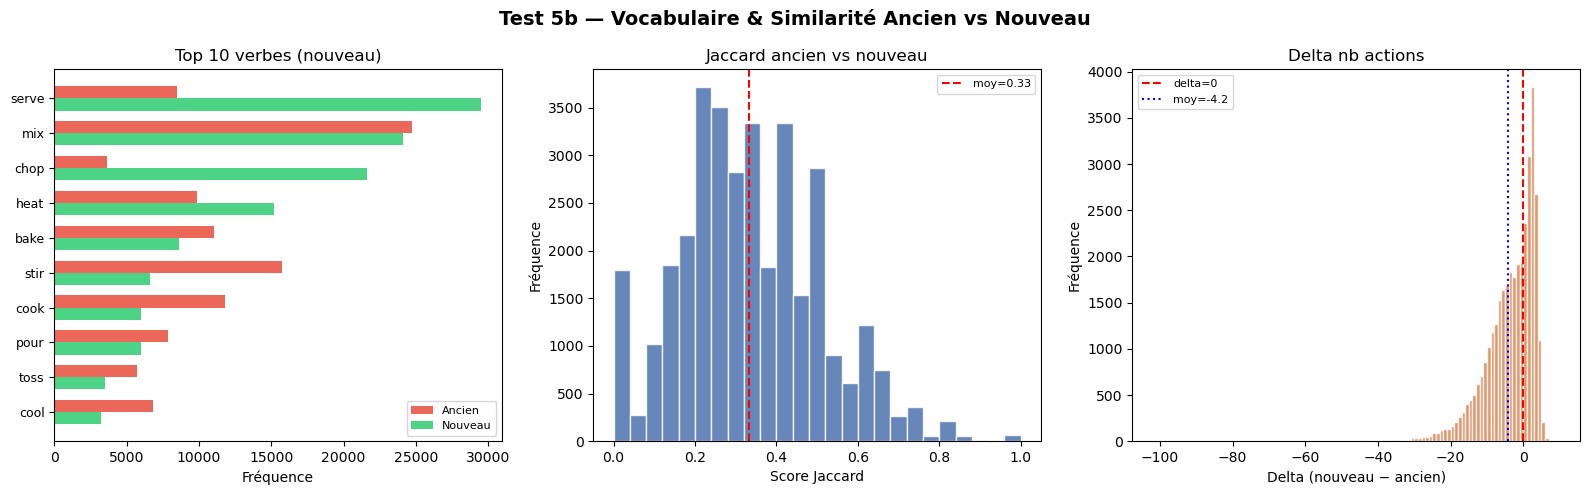

Graphique sauvegardé : img/test5b_vocabulaire_jaccard.png


In [ ]:
# ── Graphiques Test 5b 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Test 5b — Vocabulaire & Similarité Ancien vs Nouveau", fontsize=14, fontweight="bold")

# Col 0 : Top 10 verbes comparés (barres groupées)
top_verbs = list(dict(Counter(all_verbs_new).most_common(10)).keys())
freq_old = [Counter(all_verbs_old)[v] for v in top_verbs]
freq_new = [Counter(all_verbs_new)[v] for v in top_verbs]
x = np.arange(len(top_verbs))
width = 0.35
axes[0].barh(x - width/2, freq_old, width, label="Ancien", color="#e74c3c", alpha=0.85)
axes[0].barh(x + width/2, freq_new, width, label="Nouveau", color="#2ecc71", alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(top_verbs, fontsize=9)
axes[0].set_xlabel("Fréquence")
axes[0].set_title("Top 10 verbes (nouveau)")
axes[0].legend(fontsize=8)
axes[0].invert_yaxis()

# Col 1 : Distribution Jaccard ancien vs nouveau
axes[1].hist(df_t5b["jaccard_old_new"], bins=25, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].axvline(df_t5b["jaccard_old_new"].mean(), color="red", linestyle="--", linewidth=1.5,
                label=f"moy={df_t5b['jaccard_old_new'].mean():.2f}")
axes[1].set_xlabel("Score Jaccard")
axes[1].set_ylabel("Fréquence")
axes[1].set_title("Jaccard ancien vs nouveau")
axes[1].legend(fontsize=8)

# Col 2 : Distribution Delta ancien vs nouveau
axes[2].hist(df_t5b["delta_old_new"], bins=range(df_t5b["delta_old_new"].min(),
             df_t5b["delta_old_new"].max() + 2), color="#DD8452", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", linestyle="--", linewidth=1.5, label="delta=0")
axes[2].axvline(df_t5b["delta_old_new"].mean(), color="blue", linestyle=":", linewidth=1.5,
                label=f"moy={df_t5b['delta_old_new'].mean():.1f}")
axes[2].set_xlabel("Delta (nouveau − ancien)")
axes[2].set_ylabel("Fréquence")
axes[2].set_title("Delta nb actions")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("img/test5b_vocabulaire_jaccard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegardé : img/test5b_vocabulaire_jaccard.png")

---
## Test 6 — Cohérence Globale du Dataset

Vérifications structurelles :
1. **Complétude** — chaque recette possède exactement 3 variantes
2. **Doublons** — aucune combinaison (id + variante) en double
3. **Listes vides** — aucune liste d'actions vide
4. **Anti-doublon d'actions** — chaque verbe apparaît au plus 1 fois par liste

In [ ]:
# ── Test 6 : Cohérence globale du dataset 
import numpy as np

# --- 6.1 Complétude : chaque id doit avoir exactement 3 variantes 
variantes_par_id = data_wide[["id", "actions_principale", "actions_ingredients", "actions_permutation"]].copy()
variantes_par_id["nb_variantes"] = variantes_par_id[["actions_principale", "actions_ingredients", "actions_permutation"]].apply(
    lambda row: sum(1 for v in row if isinstance(v, list) and len(v) > 0), axis=1
)
n_complet   = (variantes_par_id["nb_variantes"] == 3).sum()
n_incomplet = (variantes_par_id["nb_variantes"] < 3).sum()
print("═" * 60)
print("6.1 — Complétude des variantes")
print(f"  Recettes avec 3 variantes : {n_complet:,}")
print(f"  Recettes incomplètes      : {n_incomplet:,}")
print(f"  Taux de complétude         : {n_complet / len(variantes_par_id) * 100:.2f}%")

# --- 6.2 Doublons : pas de (id) en double dans data_wide 
n_doublons = data_wide.duplicated(subset=["id"], keep=False).sum()
print(f"\n6.2 — Doublons")
print(f"  IDs en double : {n_doublons}")

# --- 6.3 Listes vides 
cols_actions = ["actions_principale", "actions_ingredients", "actions_permutation"]
labels_var   = ["principale", "ingrédients", "permutation"]
print(f"\n6.3 — Listes d'actions vides")
vides_par_var = {}
for col, lab in zip(cols_actions, labels_var):
    n_vide = data_wide[col].apply(lambda x: len(x) == 0).sum()
    vides_par_var[lab] = n_vide
    print(f"  {lab:14s} : {n_vide:,} listes vides")
total_vides = sum(vides_par_var.values())
total_listes = len(data_wide) * 3
print(f"  Total          : {total_vides:,} / {total_listes:,} ({total_vides/total_listes*100:.2f}%)")

# --- 6.4 Anti-doublon d'actions (verbe unique par liste) 
print(f"\n6.4 — Anti-doublon d'actions (verbe unique par liste)")
doublons_par_var = {}
for col, lab in zip(cols_actions, labels_var):
    n_avec_doublon = data_wide[col].apply(lambda actions: len(actions) != len(set(actions))).sum()
    doublons_par_var[lab] = n_avec_doublon
    print(f"  {lab:14s} : {n_avec_doublon:,} listes avec doublons")
total_doublons_listes = sum(doublons_par_var.values())
print(f"  Total          : {total_doublons_listes:,} / {total_listes:,} ({total_doublons_listes/total_listes*100:.2f}%)")

# --- Flag global
print(f"\n{'═' * 60}")
print("Résumé — Flags de cohérence")
data_wide["flag_t6_complet"]  = variantes_par_id["nb_variantes"].apply(lambda x: "CONFORME" if x == 3 else "FLAG_INCOMPLET")
data_wide["flag_t6_doublon"]  = "CONFORME"  # déjà vérifié au niveau dataset
data_wide["flag_t6_vide"]     = data_wide[cols_actions].apply(
    lambda row: "FLAG_LISTE_VIDE" if any(len(v) == 0 for v in row) else "CONFORME", axis=1
)
data_wide["flag_t6_anti_dup"] = data_wide[cols_actions].apply(
    lambda row: "FLAG_DOUBLON_ACTION" if any(len(v) != len(set(v)) for v in row) else "CONFORME", axis=1
)

# Flag synthèse
def flag_synthese(row):
    flags = [row["flag_t6_complet"], row["flag_t6_vide"], row["flag_t6_anti_dup"]]
    if all(f == "CONFORME" for f in flags):
        return "CONFORME"
    return " | ".join(f for f in flags if f != "CONFORME")

data_wide["flag_t6_global"] = data_wide.apply(flag_synthese, axis=1)

for flag, cnt in data_wide["flag_t6_global"].value_counts().items():
    pct = cnt / len(data_wide) * 100
    print(f"  {flag:30s} : {cnt:>6,}  ({pct:.1f}%)")

════════════════════════════════════════════════════════════
6.1 — Complétude des variantes
  Recettes avec 3 variantes : 34,591
  Recettes incomplètes      : 0
  Taux de complétude         : 100.00%

6.2 — Doublons
  IDs en double : 0

6.3 — Listes d'actions vides
  principale     : 0 listes vides
  ingrédients    : 0 listes vides
  permutation    : 0 listes vides
  Total          : 0 / 103,773 (0.00%)

6.4 — Anti-doublon d'actions (verbe unique par liste)
  principale     : 0 listes avec doublons
  ingrédients    : 0 listes avec doublons
  permutation    : 0 listes avec doublons
  Total          : 0 / 103,773 (0.00%)

════════════════════════════════════════════════════════════
Résumé — Flags de cohérence
  CONFORME                       : 34,591  (100.0%)


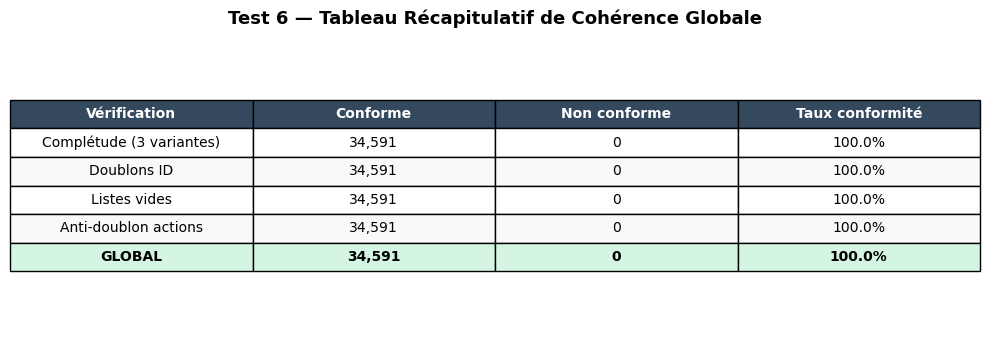

✓ Tableau sauvegardé → img/test6_coherence_globale.png


In [ ]:
# ── Tableau récapitulatif Test 6 
import matplotlib.pyplot as plt
import numpy as np

N = len(data_wide)

# Données du tableau
rows_table = [
    ["Complétude (3 variantes)",
     f"{(data_wide['flag_t6_complet']=='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_complet']!='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_complet']=='CONFORME').sum()/N*100:.1f}%"],
    ["Doublons ID",
     f"{N - n_doublons:,}",
     f"{n_doublons:,}",
     f"{(N - n_doublons)/N*100:.1f}%"],
    ["Listes vides",
     f"{N - (data_wide['flag_t6_vide']!='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_vide']!='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_vide']=='CONFORME').sum()/N*100:.1f}%"],
    ["Anti-doublon actions",
     f"{(data_wide['flag_t6_anti_dup']=='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_anti_dup']!='CONFORME').sum():,}",
     f"{(data_wide['flag_t6_anti_dup']=='CONFORME').sum()/N*100:.1f}%"],
]

# Ligne synthèse globale
n_global_ok = (data_wide["flag_t6_global"] == "CONFORME").sum()
rows_table.append([
    "GLOBAL",
    f"{n_global_ok:,}",
    f"{N - n_global_ok:,}",
    f"{n_global_ok/N*100:.1f}%"
])

col_labels = ["Vérification", "Conforme", "Non conforme", "Taux conformité"]

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis("off")
ax.set_title("Test 6 — Tableau Récapitulatif de Cohérence Globale", fontsize=13, fontweight="bold", pad=12)

table = ax.table(
    cellText=rows_table,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)

# Style en-tête
for j in range(len(col_labels)):
    table[0, j].set_facecolor("#34495e")
    table[0, j].set_text_props(color="white", fontweight="bold")

# Style lignes
for i in range(1, len(rows_table) + 1):
    for j in range(len(col_labels)):
        if i == len(rows_table):  # ligne GLOBAL
            table[i, j].set_facecolor("#d5f5e3")
            table[i, j].set_text_props(fontweight="bold")
        elif i % 2 == 0:
            table[i, j].set_facecolor("#f9f9f9")

plt.tight_layout()
plt.savefig("img/test6_coherence_globale.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Tableau sauvegardé → img/test6_coherence_globale.png")

---
## Stratégie 3 — Successions Verbales Illogiques

Détection des **erreurs de logique culinaire** dans les séquences d'actions :
- **Type A (erreur certaine)** : ex. servir avant de cuire, cuire avant de préparer
- **Type B (suspicion)** : ex. repos puis découpe, cuisson passive puis active

In [ ]:
# ── Stratégie 3 : Taxonomie des verbes + Règles de succession 

# Taxonomie : 11 catégories de verbes culinaires - importer du dossier orignale de traitement fourni 
VERB_TAXONOMY = {
    'PREPARATION_INITIALE': [
        'wash','rinse','peel','trim','chop','dice','mince','slice','cut','grate','shred','crush',
        'flatten','tear','quarter','halve','julienne','soak','thaw','defrost','marinate','season',
        'pat','dry','drain','press','score','preheat','prepare','measure','gather','assemble'
    ],
    'TRANSFORMATION_MECANIQUE': [
        'blend','puree','mash','grind','pulse','process','whisk','beat','cream','knead','roll',
        'pound','tenderize','crumble','shred','grate','sieve','strain','push','squeeze'
    ],
    'MELANGE_COMBINAISON': [
        'mix','combine','stir','fold','toss','incorporate','add','pour','sprinkle','dust',
        'coat','dip','dredge','layer','stuff','fill'
    ],
    'TRANSFERT_MANIPULATION': [
        'place','put','arrange','lay','transfer','move','flip','turn','remove','lift','spread',
        'press','pack','shape','form','mold','roll','wrap','cover','line','grease','oil','butter'
    ],
    'CUISSON_ACTIVE': [
        'fry','saute','sauté','cook','boil','simmer','stir-fry','pan-fry','deep-fry','sear',
        'brown','caramelize','toast','char','grill','broil',
        'heat','warm','reheat'
    ],
    'CUISSON_PASSIVE': [
        'bake','roast','steam','poach','braise','smoke','slow-cook','barbecue','bbq'
    ],
    'TRANSFORMATION_THERMIQUE': [
        'cool','chill','freeze','refrigerate','ice','melt'
    ],
    'ATTENTE_REPOS': [
        'rest','wait','stand','let','marinate','steep','infuse','proof','rise','set','solidify'
    ],
    'EXTRACTION_SEPARATION': [
        'drain','strain','separate','skim','sieve','filter','squeeze','press'
    ],
    'FINITION_SERVICE': [
        'serve','garnish','plate','top','drizzle','decorate','sprinkle','finish','present',
        'slice','portion','enjoy'
    ],
    'ACTIONS_SPECIALES': []  # catch-all pour verbes inconnus
}

# Mapping inverse : verbe → catégorie
VERB_TO_CAT = {}
for cat, verbs in VERB_TAXONOMY.items():
    for v in verbs:
        VERB_TO_CAT[v.lower()] = cat

def get_category(verb):
    return VERB_TO_CAT.get(verb.lower().strip(), 'ACTIONS_SPECIALES')

# ── Règles de succession 

# Type A : Successions certaines illogiques (erreur)
TYPE_A_RULES = [
    ('FINITION_SERVICE',        'PREPARATION_INITIALE',    'Finition avant préparation initiale'),
    ('FINITION_SERVICE',        'CUISSON_ACTIVE',          'Finition avant cuisson active'),
    ('FINITION_SERVICE',        'CUISSON_PASSIVE',         'Finition avant cuisson passive'),
    ('FINITION_SERVICE',        'TRANSFORMATION_MECANIQUE','Finition avant transformation'),
    ('CUISSON_ACTIVE',          'PREPARATION_INITIALE',    'Cuisson avant préparation initiale'),
    ('CUISSON_PASSIVE',         'PREPARATION_INITIALE',    'Cuisson passive avant préparation initiale'),
    ('TRANSFORMATION_THERMIQUE','CUISSON_ACTIVE',          'Refroidissement puis cuisson active'),
]

# Type B : Successions suspectes (avertissement)
TYPE_B_RULES = [
    ('ATTENTE_REPOS',           'PREPARATION_INITIALE',    'Repos puis découpe (ordre inhabituel)'),
    ('CUISSON_PASSIVE',         'CUISSON_ACTIVE',          'Cuisson passive suivie de cuisson active'),
    ('FINITION_SERVICE',        'MELANGE_COMBINAISON',     'Finition puis mélange'),
    ('EXTRACTION_SEPARATION',   'MELANGE_COMBINAISON',     'Séparation puis mélange'),
]

def detect_violations(action_list, rules, label):
    """Retourne la liste des violations trouvées dans une séquence d'actions."""
    violations = []
    categories = [get_category(v) for v in action_list]
    for i in range(len(categories) - 1):
        cat_cur  = categories[i]
        cat_next = categories[i + 1]
        for (from_cat, to_cat, description) in rules:
            if cat_cur == from_cat and cat_next == to_cat:
                violations.append({
                    'type': label,
                    'position': i,
                    'verb_from': action_list[i],
                    'cat_from': cat_cur,
                    'verb_to': action_list[i + 1],
                    'cat_to': cat_next,
                    'rule': description
                })
    return violations

print("Taxonomie chargée.")
print(f"  Catégories : {len(VERB_TAXONOMY)}")
print(f"  Verbes mappés : {len(VERB_TO_CAT)}")
print(f"  Règles Type A (erreurs) : {len(TYPE_A_RULES)}")
print(f"  Règles Type B (suspicions) : {len(TYPE_B_RULES)}")

Taxonomie chargée.
  Catégories : 11
  Verbes mappés : 144
  Règles Type A (erreurs) : 7
  Règles Type B (suspicions) : 4


In [ ]:
# ── Stratégie 3 : Exécution sur variante_principale - code copier du dossier origninale fourni par Andreas
records_s3 = []

for _, row in data_wide.iterrows():
    recipe_id = row['id']
    actions   = row['actions_principale']

    if not actions:
        continue

    viol_a = detect_violations(actions, TYPE_A_RULES, 'A')
    viol_b = detect_violations(actions, TYPE_B_RULES, 'B')

    records_s3.append({
        'id': recipe_id,
        'nb_actions': len(actions),
        'violations_A': len(viol_a),
        'violations_B': len(viol_b),
        'violations_total': len(viol_a) + len(viol_b),
        'flag_s3': 'FLAG_ERREUR_CRITIQUE' if viol_a
                   else ('FLAG_SUSPICION' if viol_b else 'CONFORME')
    })

df_s3 = pd.DataFrame(records_s3)

print('=' * 60)
print('STRATÉGIE 3 — SUCCESSIONS VERBALES ILLOGIQUES')
print('=' * 60)
print(f'Total recettes analysées : {len(df_s3):,}')
print()
print('Distribution des flags :')
for flag, count in df_s3['flag_s3'].value_counts().items():
    pct = count / len(df_s3) * 100
    icon = '✅' if flag == 'CONFORME' else ('❌' if 'CRITIQUE' in flag else '⚠️')
    print(f'  {icon} {flag:<30} {count:>6,}  ({pct:.2f}%)')
print()
print(f'Violations Type A (moy/recette) : {df_s3["violations_A"].mean():.3f}')
print(f'Violations Type B (moy/recette) : {df_s3["violations_B"].mean():.3f}')
print(f'Recettes avec ≥1 violation A    : {(df_s3["violations_A"] > 0).sum():,}')
print(f'Recettes avec ≥1 violation B    : {(df_s3["violations_B"] > 0).sum():,}')

STRATÉGIE 3 — SUCCESSIONS VERBALES ILLOGIQUES
Total recettes analysées : 34,591

Distribution des flags :
  ✅ CONFORME                       29,451  (85.14%)
  ❌ FLAG_ERREUR_CRITIQUE            3,418  (9.88%)
  ⚠️ FLAG_SUSPICION                  1,722  (4.98%)

Violations Type A (moy/recette) : 0.103
Violations Type B (moy/recette) : 0.058
Recettes avec ≥1 violation A    : 3,418
Recettes avec ≥1 violation B    : 1,942


In [ ]:
# ── Stratégie 3 : Top violations par règle
all_violations = []
for _, row in data_wide.iterrows():
    actions = row['actions_principale']
    if not actions:
        continue
    all_violations += detect_violations(actions, TYPE_A_RULES, 'A')
    all_violations += detect_violations(actions, TYPE_B_RULES, 'B')

if all_violations:
    df_viol = pd.DataFrame(all_violations)
    print('Top 10 règles violées :')
    top_rules = df_viol.groupby(['type','rule']).size().sort_values(ascending=False).head(10)
    print(top_rules.to_string())
    print()
    print('Top 10 paires de verbes problématiques :')
    df_viol['pair'] = df_viol['verb_from'] + ' → ' + df_viol['verb_to']
    print(df_viol['pair'].value_counts().head(10).to_string())
else:
    print('Aucune violation détectée.')

Top 10 règles violées :
type  rule                                      
A     Cuisson avant préparation initiale            1851
B     Séparation puis mélange                       1067
A     Finition avant cuisson passive                 530
B     Finition puis mélange                          490
      Cuisson passive suivie de cuisson active       364
A     Refroidissement puis cuisson active            328
      Finition avant cuisson active                  321
      Cuisson passive avant préparation initiale     269
      Finition avant préparation initiale            180
      Finition avant transformation                   97

Top 10 paires de verbes problématiques :
pair
cook → season      549
sprinkle → bake    365
simmer → season    346
drain → mix        302
heat → season      226
melt → cook        130
drain → toss       108
slice → mix         84
drizzle → bake      76
melt → saute        72


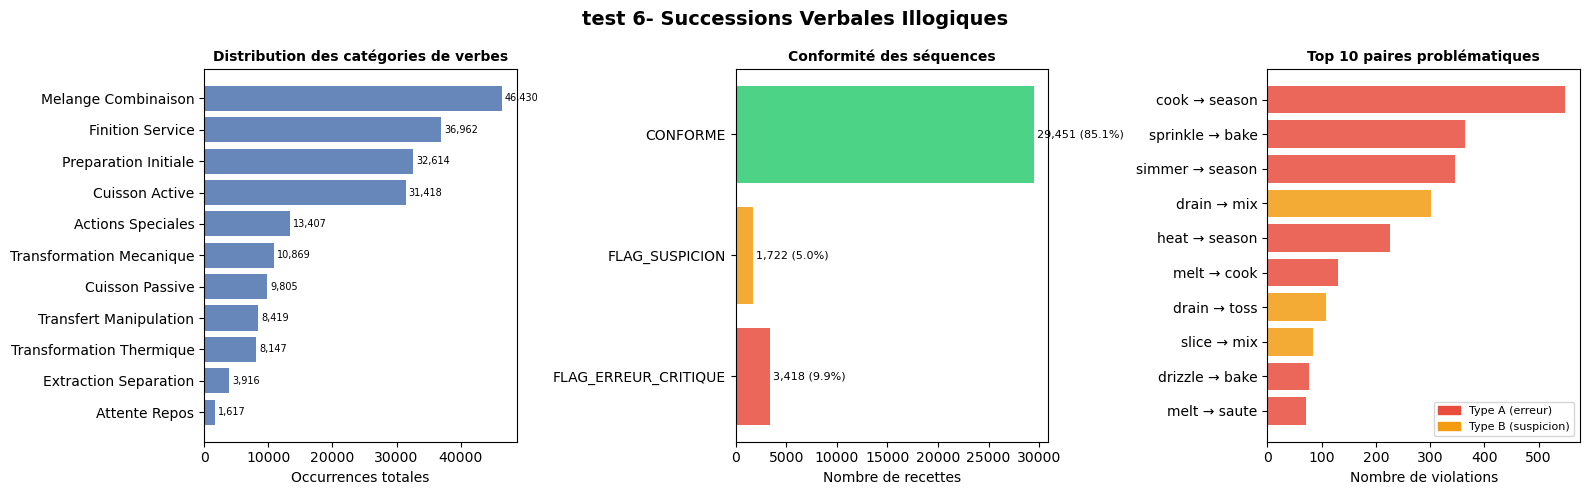

✓ Graphiques sauvegardés → img/strategie3_graphiques.png


In [ ]:
# ── Graphiques Stratégie 3 
import matplotlib.pyplot as plt
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("test 6- Successions Verbales Illogiques", fontsize=14, fontweight="bold")

# ── Col 0 : Distribution des catégories de verbes 
all_verbs = [v for actions in data_wide['actions_principale'] if actions for v in actions]
all_cats  = [get_category(v) for v in all_verbs]
cat_counts = Counter(all_cats)
sorted_cats = sorted(cat_counts.items(), key=lambda x: -x[1])
labels_cat = [c[0].replace('_', ' ').title() for c in sorted_cats]
values_cat = [c[1] for c in sorted_cats]
bars0 = axes[0].barh(labels_cat, values_cat, color='#4C72B0', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel("Occurrences totales")
axes[0].set_title("Distribution des catégories de verbes", fontsize=10, fontweight="bold")
for bar, val in zip(bars0, values_cat):
    axes[0].text(bar.get_width() + max(values_cat)*0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:,}", va='center', fontsize=7)

# ── Col 1 : Flags (barres horizontales) 
flag_order  = ['CONFORME', 'FLAG_SUSPICION', 'FLAG_ERREUR_CRITIQUE']
flag_colors = {'CONFORME': '#2ecc71', 'FLAG_SUSPICION': '#f39c12', 'FLAG_ERREUR_CRITIQUE': '#e74c3c'}
flag_counts = df_s3['flag_s3'].value_counts()
y_flags = [f for f in flag_order if f in flag_counts.index]
v_flags = [flag_counts[f] for f in y_flags]
bars1 = axes[1].barh(y_flags, v_flags, color=[flag_colors[f] for f in y_flags], alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_xlabel("Nombre de recettes")
axes[1].set_title("Conformité des séquences", fontsize=10, fontweight="bold")
for bar, val in zip(bars1, v_flags):
    pct = val / len(df_s3) * 100
    axes[1].text(bar.get_width() + max(v_flags)*0.01, bar.get_y() + bar.get_height()/2,
                 f"{val:,} ({pct:.1f}%)", va='center', fontsize=8)

# ── Col 2 : Top 10 paires de verbes problématiques 
if all_violations:
    df_viol_g = pd.DataFrame(all_violations)
    df_viol_g['pair'] = df_viol_g['verb_from'] + ' → ' + df_viol_g['verb_to']
    top10 = df_viol_g.groupby(['pair', 'type']).size().reset_index(name='count')
    top10 = top10.sort_values('count', ascending=True).tail(10)
    bar_colors = ['#e74c3c' if t == 'A' else '#f39c12' for t in top10['type']]
    axes[2].barh(top10['pair'], top10['count'], color=bar_colors, alpha=0.85)
    axes[2].set_xlabel("Nombre de violations")
    axes[2].set_title("Top 10 paires problématiques", fontsize=10, fontweight="bold")
    # Légende
    from matplotlib.patches import Patch
    axes[2].legend(handles=[Patch(color='#e74c3c', label='Type A (erreur)'),
                            Patch(color='#f39c12', label='Type B (suspicion)')],
                   loc='lower right', fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'Aucune violation\ndétectée',
                 ha='center', va='center', transform=axes[2].transAxes, fontsize=12)
    axes[2].set_title("Top 10 paires problématiques", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("img/strategie3_graphiques.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Graphiques sauvegardés → img/strategie3_graphiques.png")

Fin du Notebook: Pour ecrire ce notebook je me suis inspiré,j'ai copié certaines cellule du code fourni par Andreas